In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from ipywidgets import interact, IntSlider

def rad(x, y):
    x = np.array(x)
    y = np.array(y)
    x /= np.linalg.norm(x)
    y /= np.linalg.norm(y)
    return np.arccos(np.clip(np.dot(x, y), -1.0, 1.0))

In [2]:
results = []
avg_results = []

for model in ("hubert-large-en", ):
# for model in ("hubert-large-en", "hubert-large-as", "hubert-large-ja", "hubert-large-ko", "hubert-large-zh"):
    for layer in tqdm(range(25)):
        df = pd.read_pickle(f"data/sylber-{model}-{layer}.pkl")
        feats = []
        for continuum, _df in df.groupby("continuum"):
            _df = _df.sort_values("step").set_index("step")
            fl = _df.loc[1].feat
            fr = _df.loc[9].feat
            f_feats = df[((df.step == 1) & (df.phn_start != _df.loc[1].phn_start) & (df.phn_start != _df.loc[1].phn_end)) | ((df.step == 9) & (df.phn_end != _df.loc[1].phn_start) & (df.phn_end != _df.loc[1].phn_end))].feat.to_list()
            other_rad = np.mean([rad(fl, f) for f in f_feats] + [rad(fr, f) for f in f_feats])

            results.append({
                "extreme": rad(fl, fr),
                "medium": np.array([
                    rad(_df.loc[i].feat, _df.loc[i+1].feat)
                    for i in range(1, 9)
                ]).sum(),
                "other": other_rad,
                "continuum": continuum,
                "layer": layer,
                "model": model,
            })
            feats.append(_df.loc[1].feat)
            feats.append(_df.loc[9].feat)

        # avg_dist = np.mean([
        #     rad(feats[i], feats[j])
        #     for i in range(len(feats))
        #     for j in range(i+1, len(feats))
        # ])
        # avg_results.append({
        #     "avg": avg_dist,
        #     "layer": layer,
        #     "model": model,
        # })
results = pd.DataFrame(results)
# avg_results = pd.DataFrame(avg_results)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 25/25 [00:11<00:00,  2.19it/s]


In [97]:
model = ["hubert-large-en", "hubert-large-as", "hubert-large-ja", "hubert-large-ko", "hubert-large-zh"][0]

def plot_frame(frame_idx):
    _r = results[(results.model == model) & (results.layer == frame_idx)]
    colors = [{"vowels": "C0", "consonants": "C1"}[c.split("-")[0]] for c in _r.continuum]
    plt.scatter(_r.medium / np.pi, _r.extreme / np.pi, c=colors, s=3)
    plt.xlabel("Mediums")
    plt.ylabel("Extremes")

    avg = avg_results[(avg_results.model == model) & (avg_results.layer == frame_idx)].iloc[0].avg
    plt.axhline(avg, ls="--")
    plt.axvline(avg, ls="--")
    # plt.grid(True)
    plt.xlim(0.0, avg*2)
    plt.ylim(0.0, avg*2)
    plt.show()

interact(plot_frame, frame_idx=IntSlider(min=0, max=24, step=1, value=0))

interactive(children=(IntSlider(value=0, description='frame_idx', max=24), Output()), _dom_classes=('widget-in…

<function __main__.plot_frame(frame_idx)>

In [20]:
def plot_frame(frame_idx):
    model = ["hubert-large-en", "hubert-large-as", "hubert-large-ja", "hubert-large-ko", "hubert-large-zh"][frame_idx]
    _r = results[(results.model == model) & (results.layer == 24)]
    colors = [{"vowels": "C0", "consonants": "C1"}[c.split("-")[0]] for c in _r.continuum]
    plt.scatter(_r.medium / np.pi, _r.extreme / np.pi, c=colors, s=3)
    plt.xlabel("Mediums")
    plt.ylabel("Extremes")
    # plt.xlim(0.0, 1.0)
    # plt.ylim(0.0, 1.0)
    plt.title(model)
    plt.grid(True)
    plt.show()

interact(plot_frame, frame_idx=IntSlider(min=0, max=4, step=1, value=0))

interactive(children=(IntSlider(value=0, description='frame_idx', max=4), Output()), _dom_classes=('widget-int…

<function __main__.plot_frame(frame_idx)>

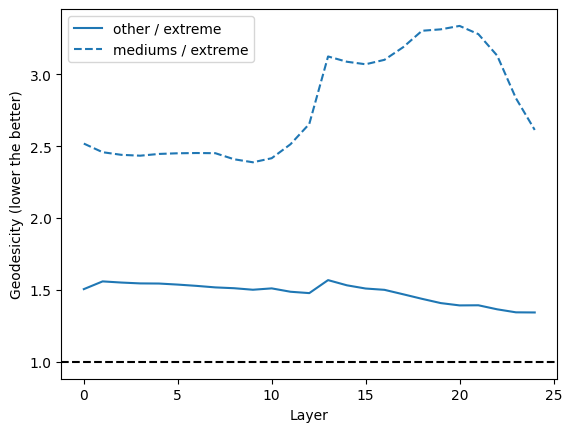

In [3]:
for i, model in enumerate(results.model.unique()):
    _r = results[results.model == model].copy()
    # _ravg = avg_results[avg_results.model == model]
    # all_avg = _ravg.sort_values("layer").avg.to_numpy()
    # extreme_avg = _r.groupby("layer").extreme.mean().sort_index().to_numpy()
    # relative_dist = all_avg / extreme_avg

    _r["rel"] = _r["other"] / _r["extreme"]
    _r["geod"] = _r["medium"] / _r["extreme"]
    # medium_avg = _r.groupby("layer").medium.mean().sort_index().to_numpy()
    # plt.plot(medium_avg / extreme_avg, "-", label=model, c=f"C{i}")

    # plt.plot(_r.groupby("layer")["rel"].mean().sort_index().to_numpy(), "-", c=f"C{i}", label=model)
    # plt.plot(_r.groupby("layer")["geod"].mean().sort_index().to_numpy(), "--", c=f"C{i}")
    plt.plot(_r.groupby("layer")["rel"].mean().sort_index().to_numpy(), "-", c=f"C{i}", label="other / extreme")
    plt.plot(_r.groupby("layer")["geod"].mean().sort_index().to_numpy(), "--", c=f"C{i}", label="mediums / extreme")
    # plt.plot(medium_avg / extreme_avg, "-", label="medium/extreme", c=f"C{i}")
    # plt.plot(all_avg / extreme_avg, "--", label="all/extreme", c=f"C{i}")
    break
plt.axhline(1, c="black", ls="--")
plt.xlabel("Layer")
plt.ylabel("Geodesicity (lower the better)")
# plt.title(model)
plt.legend()
plt.show()

# plt.legend()


In [25]:
results[(results.model == "hubert-large-en")]

,extreme,medium,other,continuum,layer,model
0,1.037642,2.884974,1.006474,consonants-bad-pad,0,hubert-large-en
1,0.821367,2.325133,0.956797,consonants-ball-mall,0,hubert-large-en
2,0.928474,3.315421,0.991116,consonants-ban-pan,0,hubert-large-en
3,0.980772,2.880649,0.998945,consonants-bar-par,0,hubert-large-en
4,0.996157,2.762767,0.999765,consonants-bay-pay,0,hubert-large-en
...,...,...,...,...,...,...
1795,1.305663,2.506525,1.332427,vowels-ta-te,24,hubert-large-en
1796,0.991719,1.341708,1.371909,vowels-ta-tow,24,hubert-large-en
1797,0.701555,1.166678,1.312310,vowels-te-ti,24,hubert-large-en
1798,1.201198,2.125794,1.317486,vowels-ti-tu,24,hubert-large-en


Text(0, 0.5, 'Extreme Radians / pi (lower the better)')

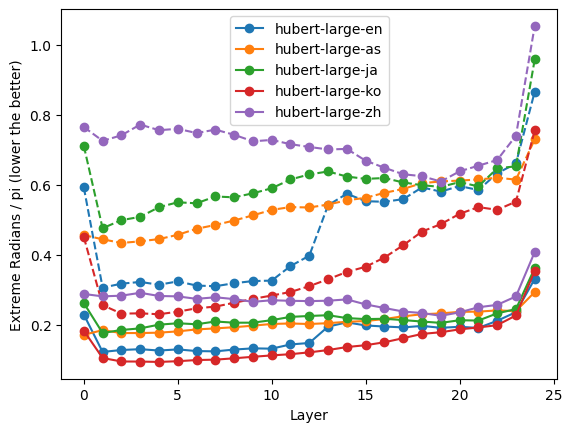

In [101]:
for i, model in enumerate(results.model.unique()):
    _r = results[results.model == model]
    plt.plot([
        _r[_r.layer == layer].extreme.mean() / np.pi
        for layer in range(25)
    ], "o-", label=model, c=f"C{i}")
    plt.plot([
        _r[_r.layer == layer].medium.mean() / np.pi
        for layer in range(25)
    ], "o--", c=f"C{i}")
plt.legend()
# plt.axhline(1, c="black", ls="--")
plt.xlabel("Layer")
plt.ylabel("Extreme Radians / pi (lower the better)")

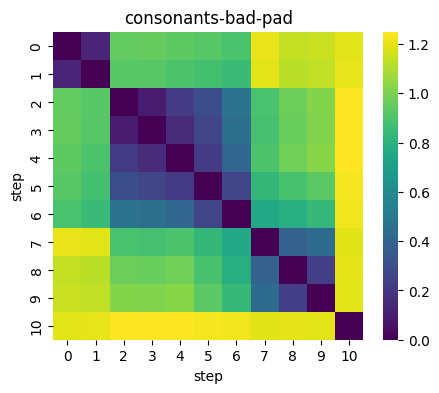

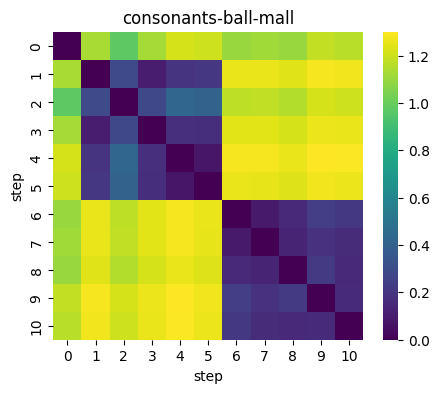

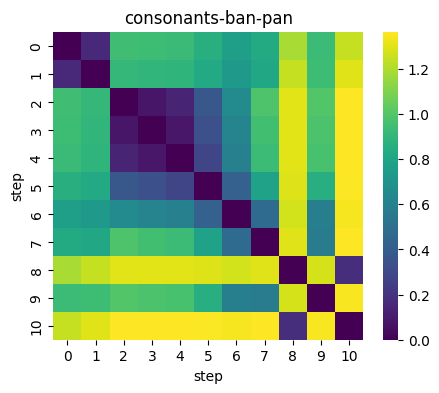

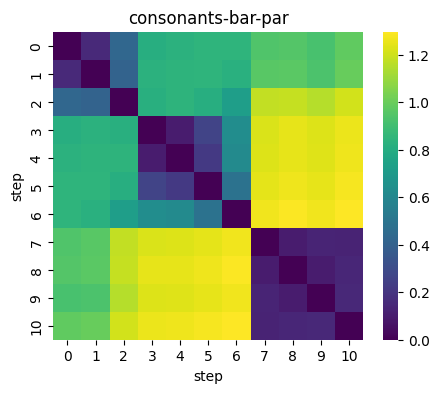

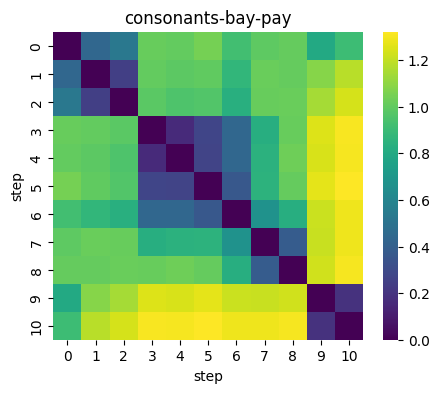

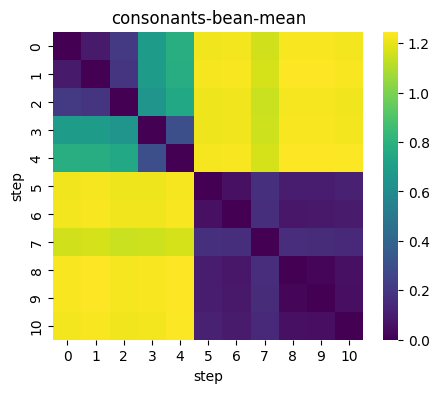

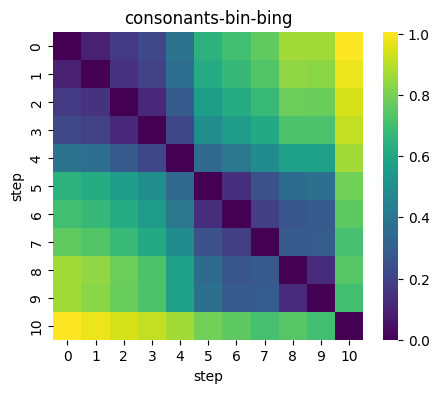

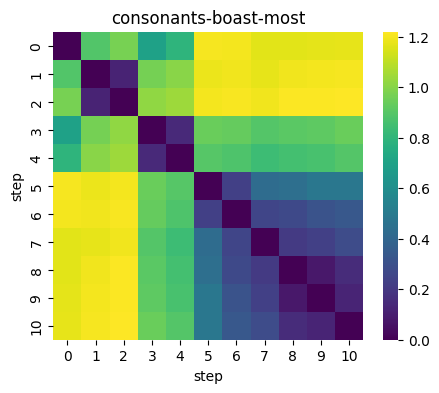

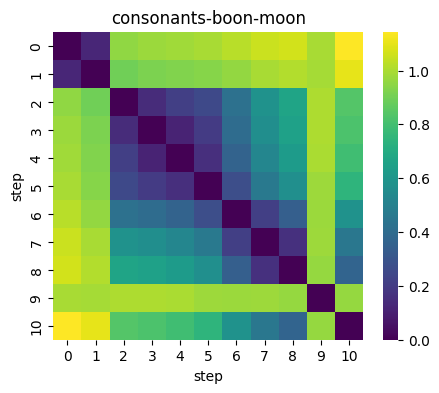

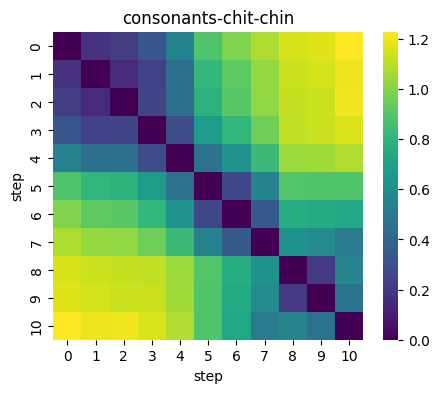

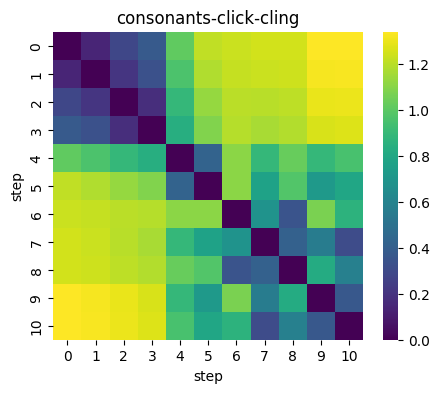

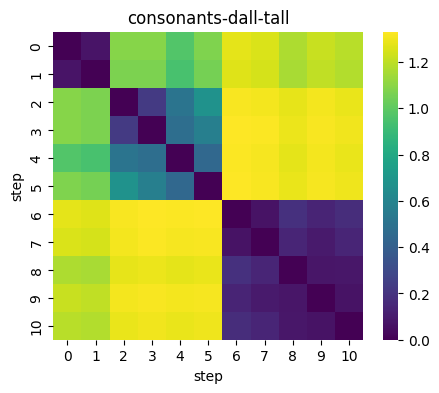

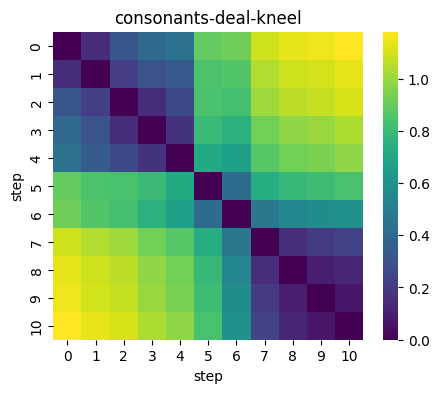

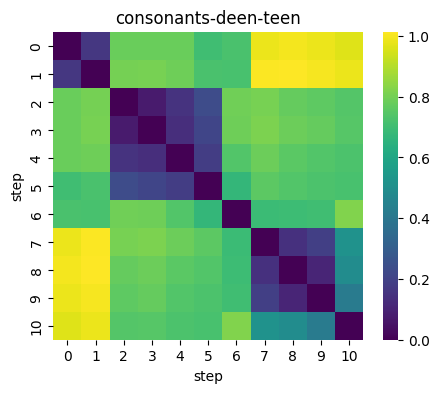

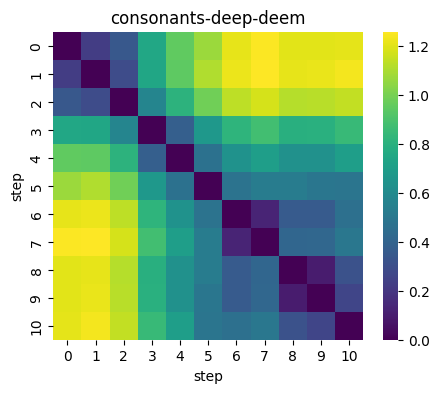

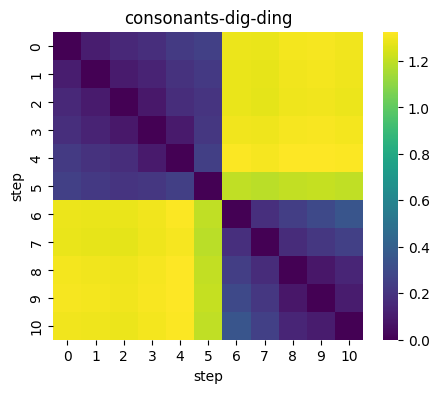

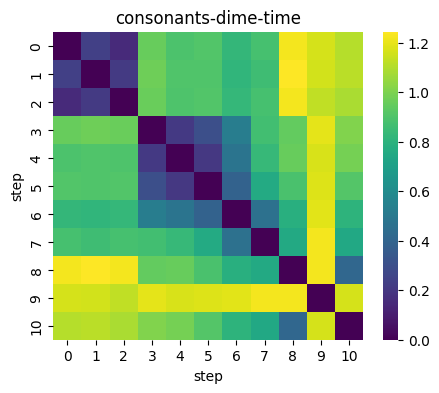

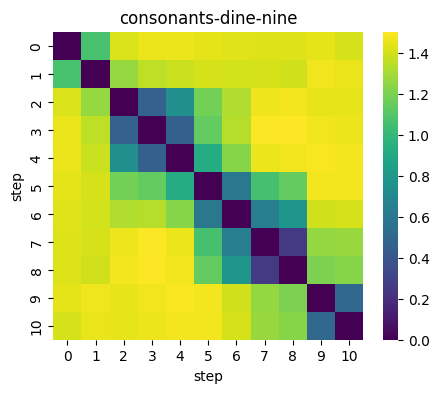

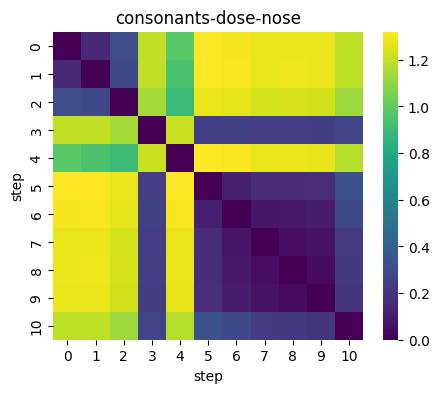

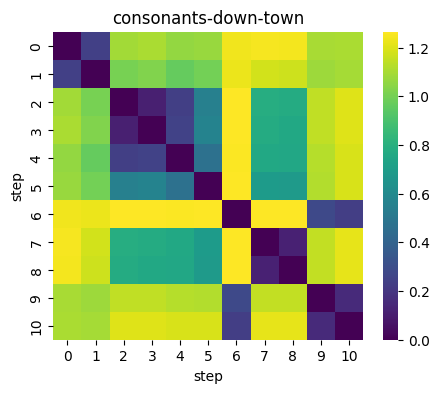

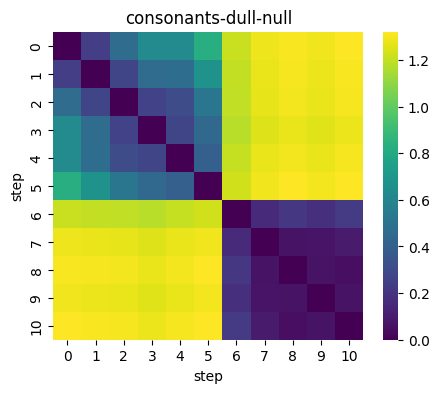

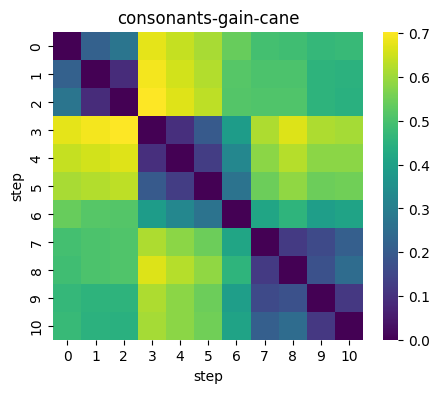

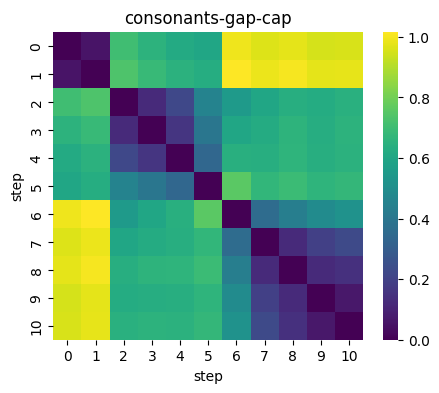

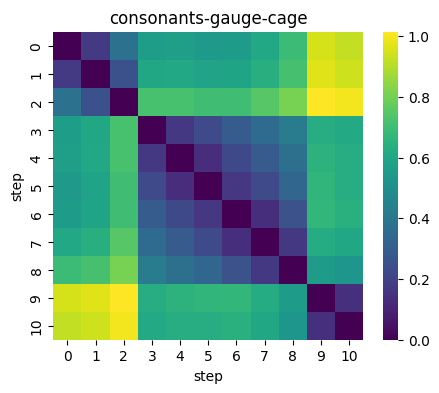

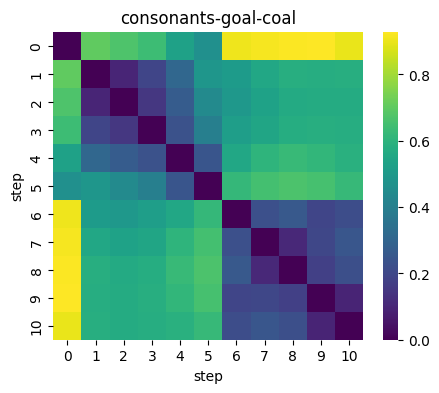

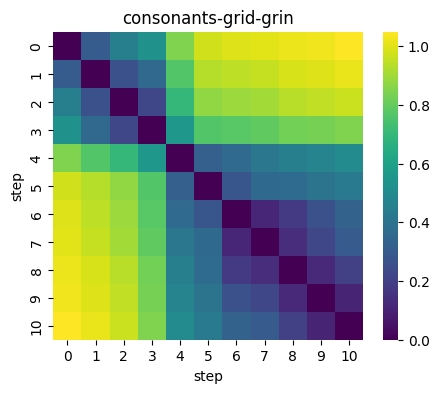

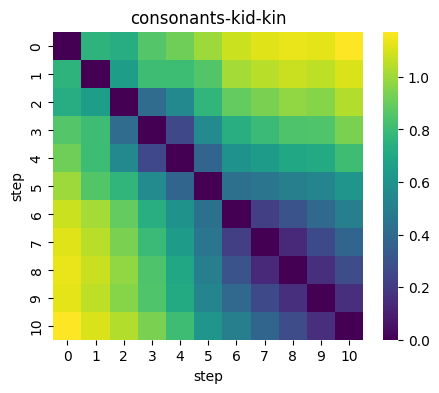

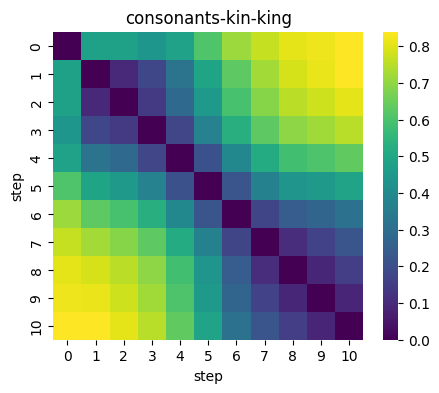

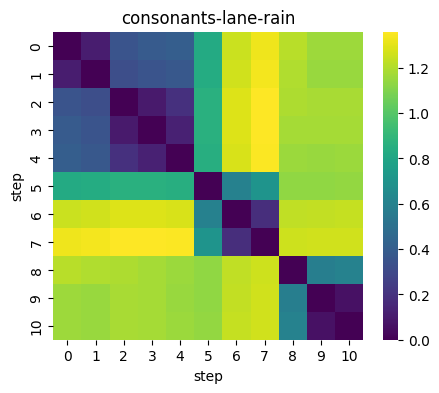

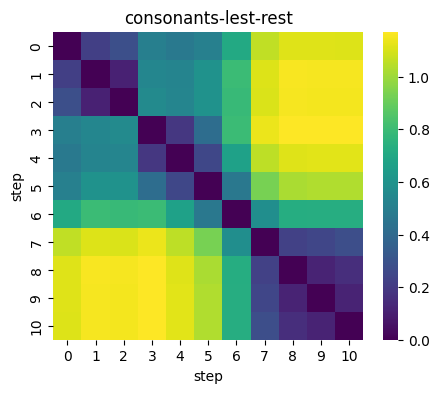

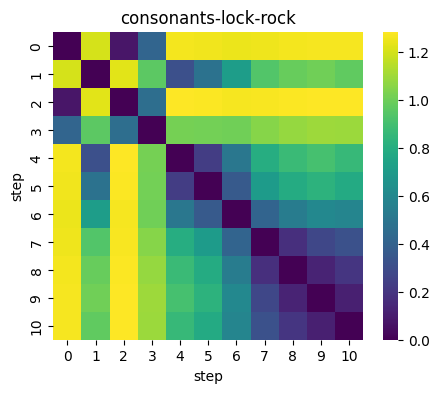

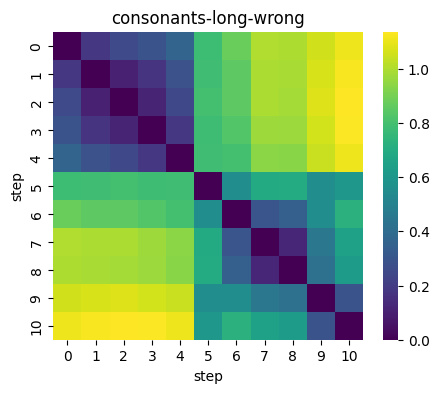

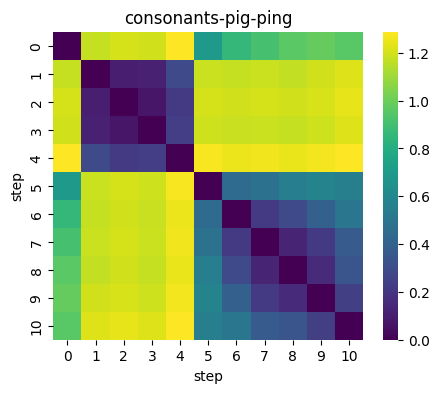

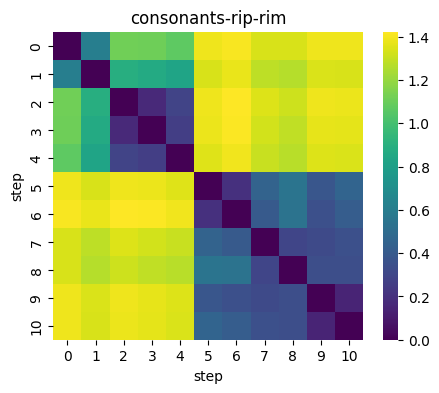

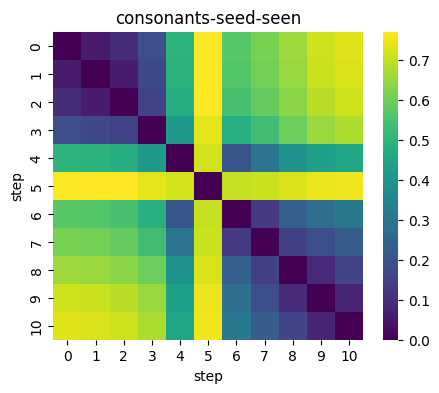

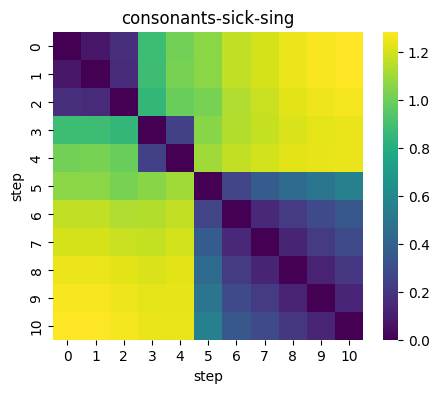

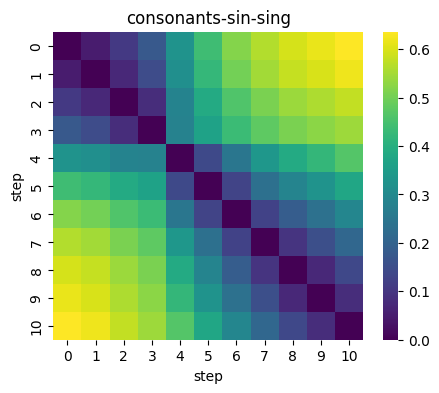

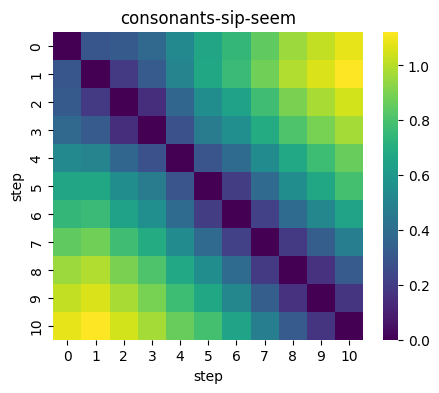

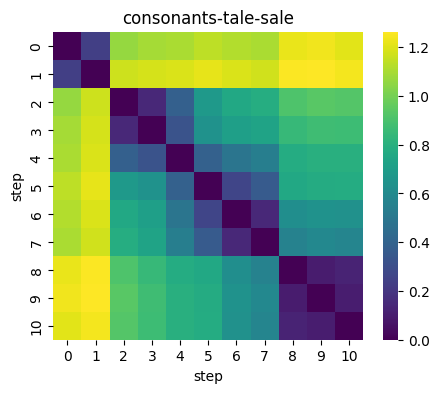

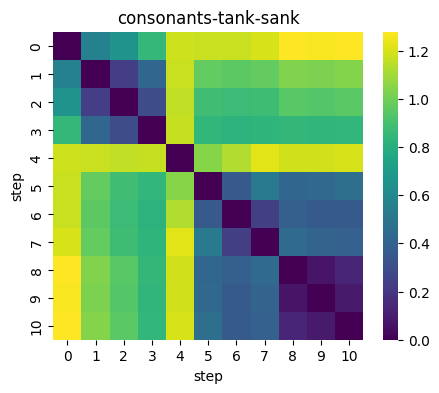

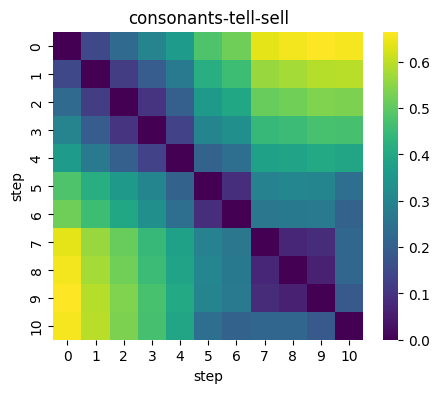

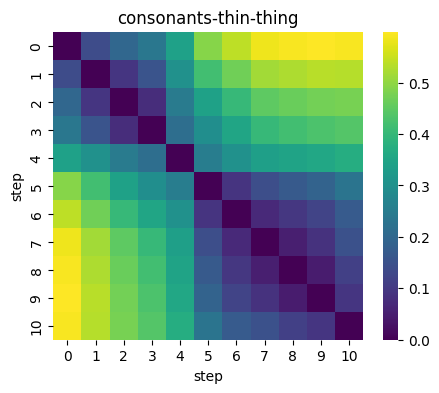

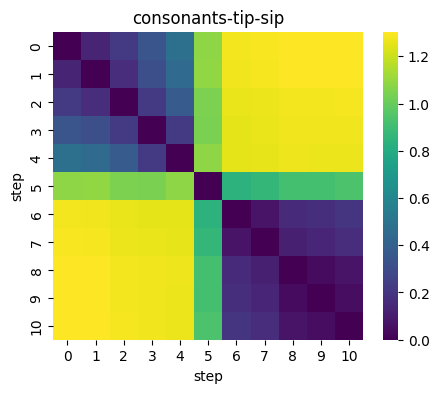

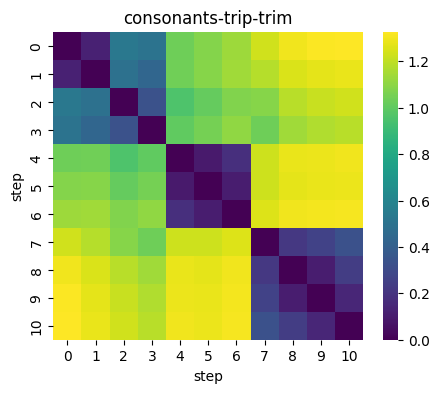

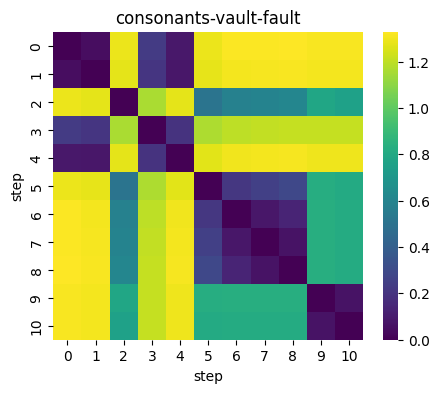

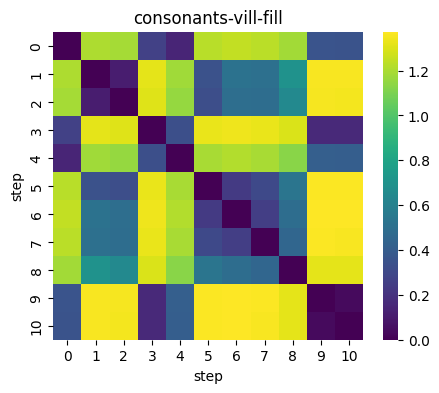

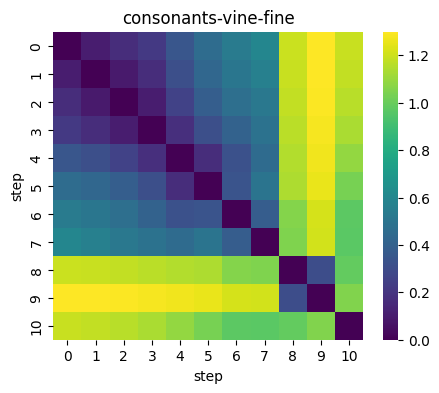

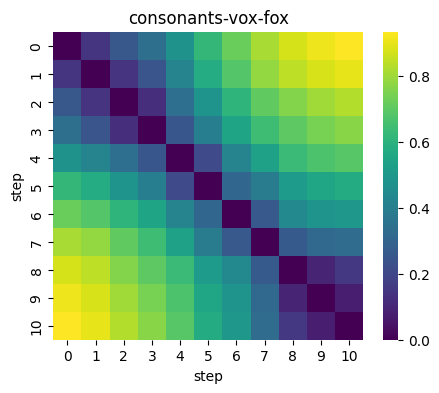

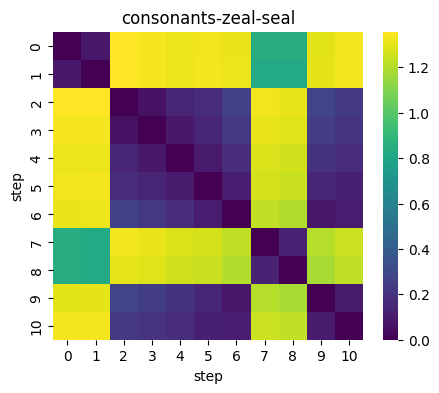

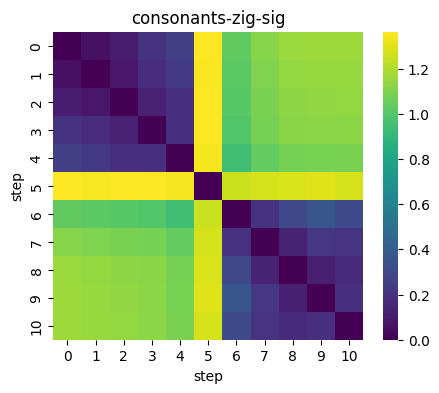

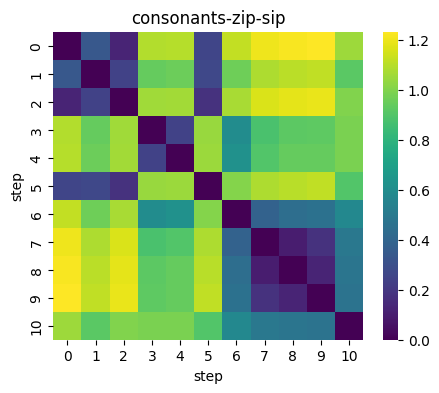

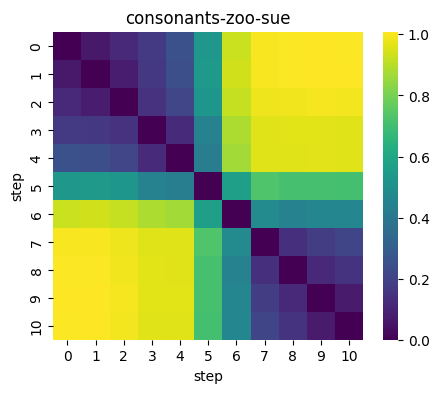

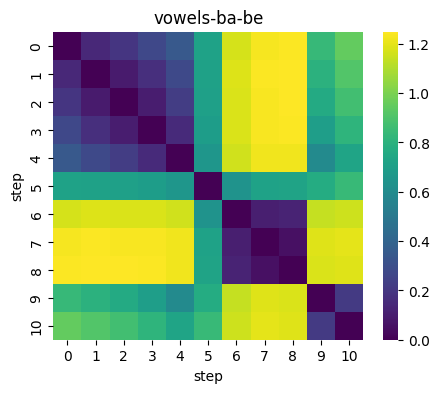

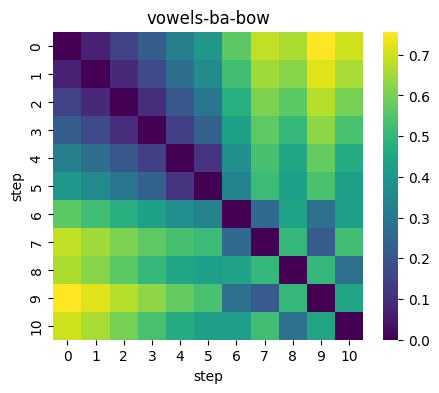

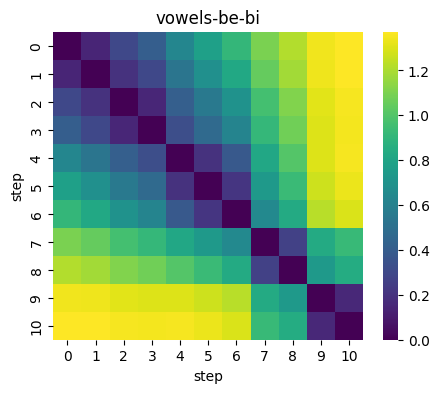

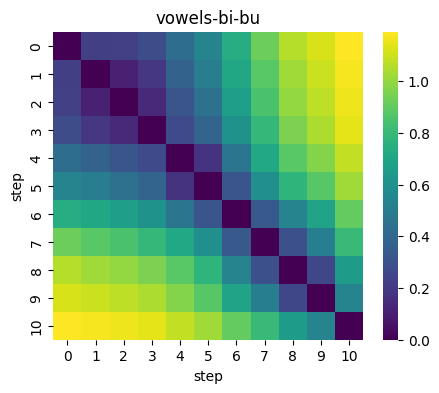

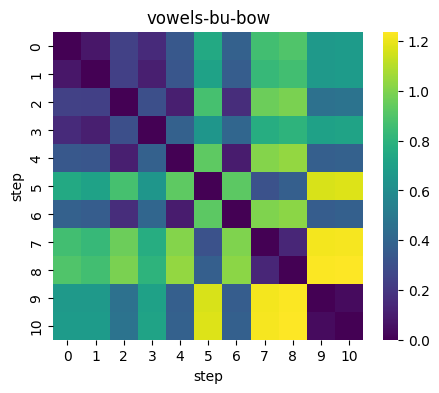

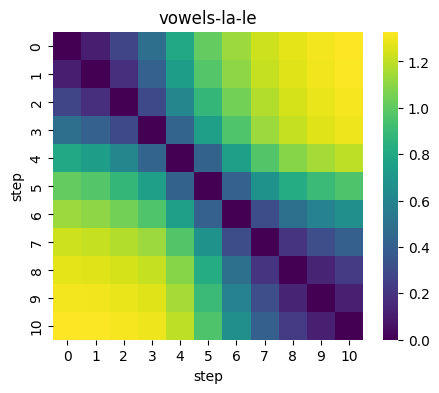

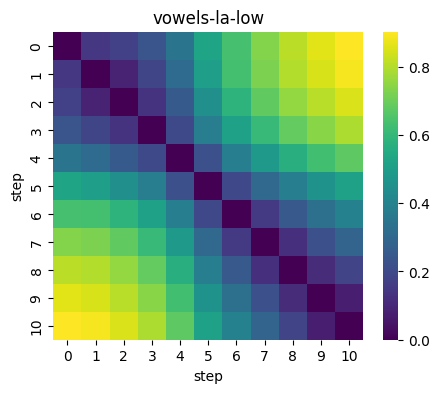

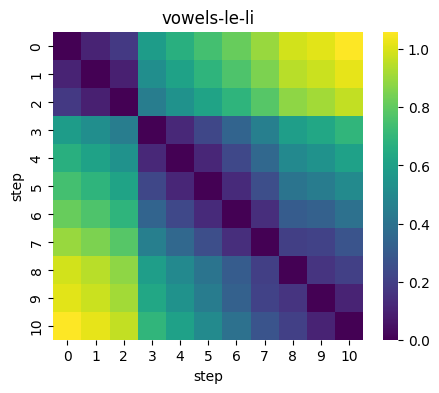

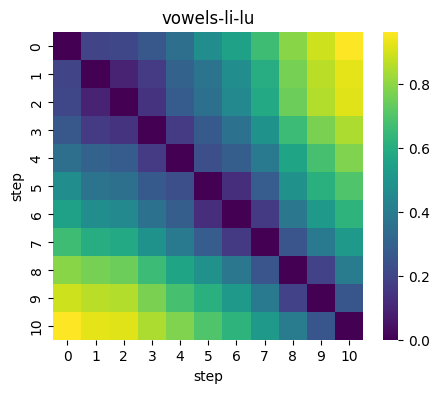

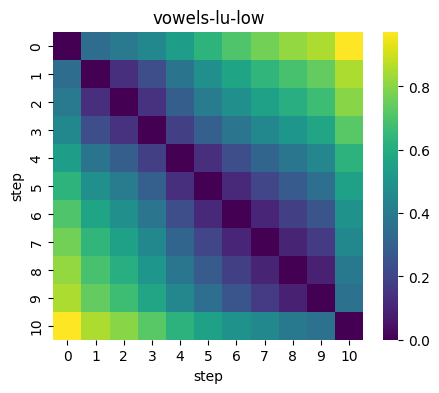

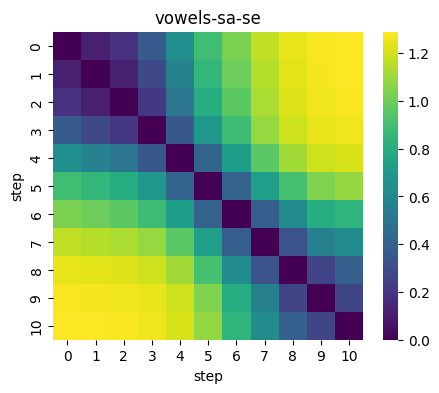

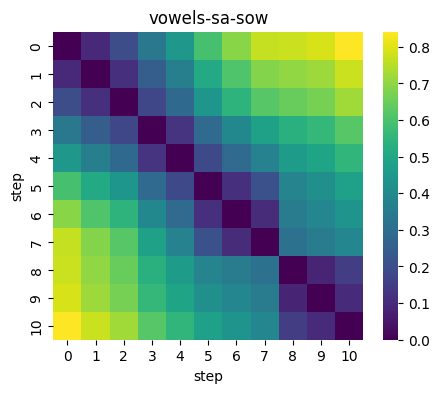

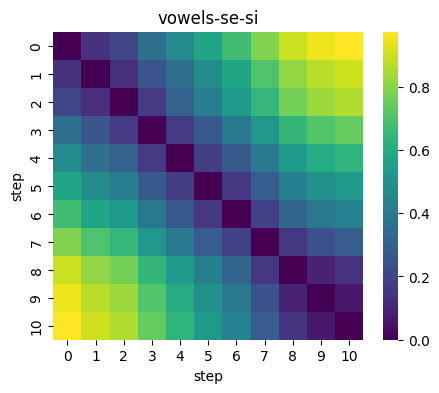

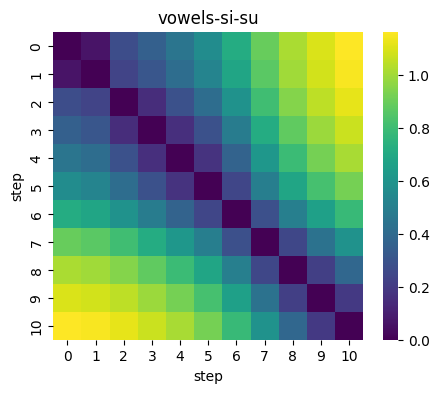

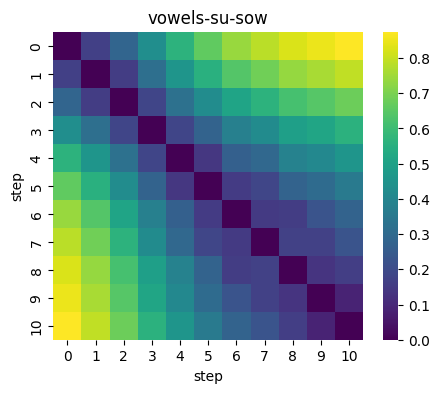

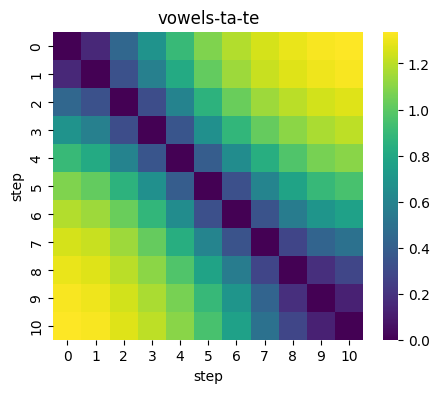

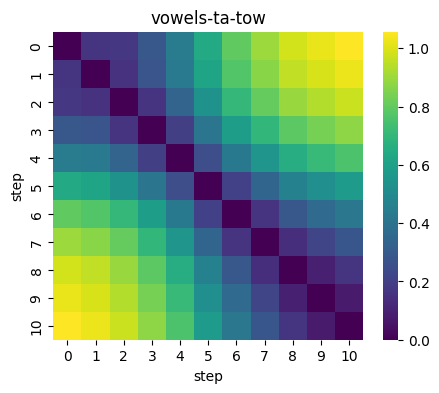

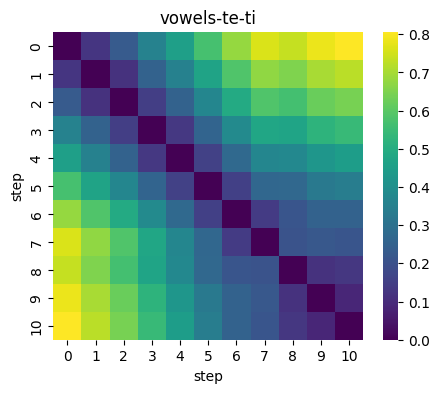

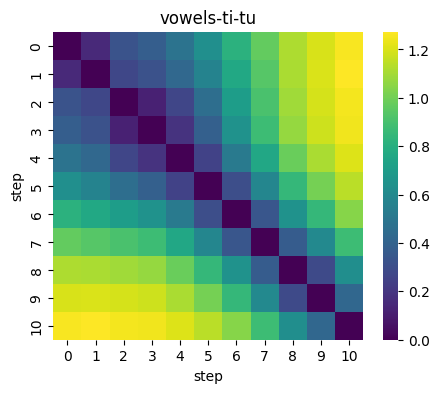

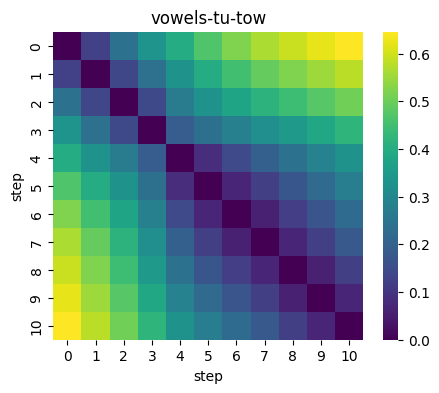

In [8]:
import seaborn
import pandas as pd
import numpy as np

model = "hubert-large-en"
df = pd.read_pickle(f"data/sylber-{model}-24.pkl")

for i, cont in enumerate(df.continuum.unique()):
    _df = df[df.continuum == cont].copy().sort_values("step").reset_index()
    n = len(_df)
    sim_matrix = np.zeros((n, n))
    
    # Compute similarity for all pairs
    for i in range(n):
        for j in range(n):
            sim_matrix[i, j] = rad(_df['feat'][i], _df['feat'][j])
    sim_df = pd.DataFrame(sim_matrix, index=_df['step'], columns=_df['step'])

    # Plot heatmap
    plt.figure(figsize=(5, 4))
    seaborn.heatmap(sim_df, cmap="viridis")
    plt.title(cont)
    plt.show()
    if i > 10:
        break

In [46]:
from IPython.display import Audio, display
import librosa

_df = df[df.phn_start == "v"]
for _, row in _df.iterrows():
    y, sr = librosa.load(row.audio_path, sr=16000)
    assert sr == 16000
    print(row.continuum, row.step)
    display(Audio(y[int(row["min"] * sr):int(row["max"] * sr)], rate=sr))
    break

consonants-vault-fault 0


In [1]:
import umap
import pandas as pd
import matplotlib.pyplot as plt

model = "hubert-large-en"
df = pd.read_pickle(f"data/sylber-{model}-24.pkl")
# df = df[(df.step == 1) | (df.step == 9)].reset_index()
feats = df.feat.to_list()
reducer = umap.UMAP(metric="cosine")
embs = reducer.fit_transform(feats, n_neighbors=10)

/home/kwanghec/unbox-w2v-convnet/envs/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


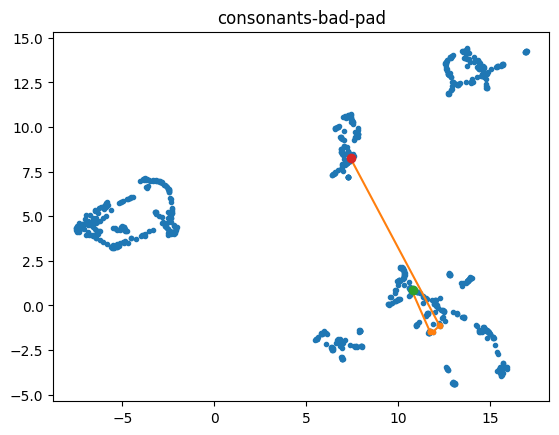

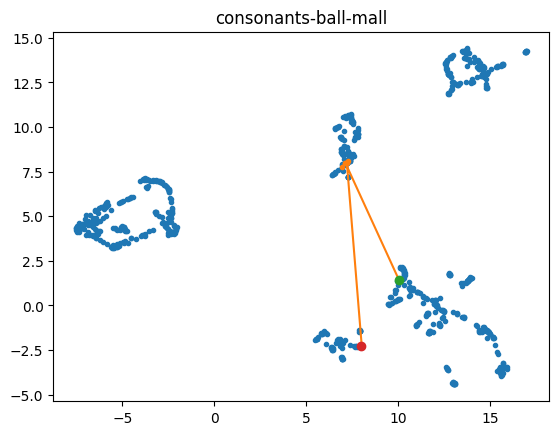

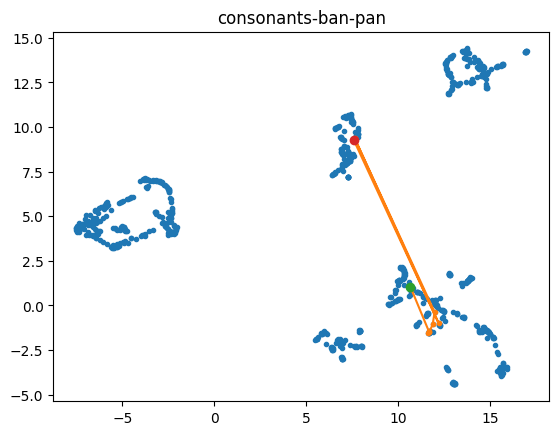

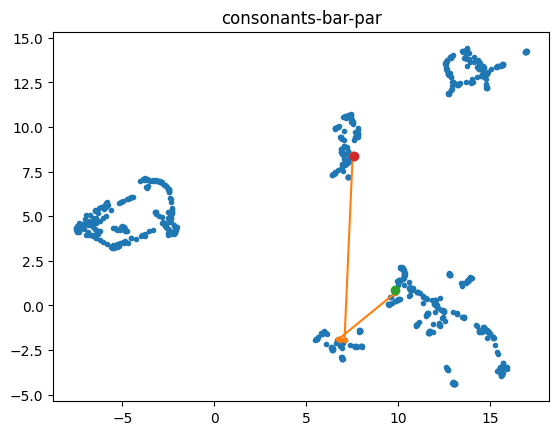

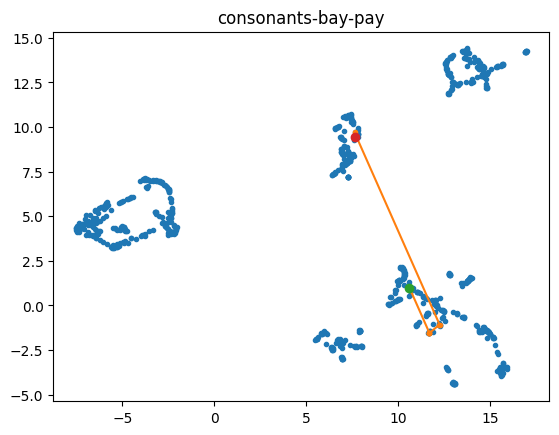

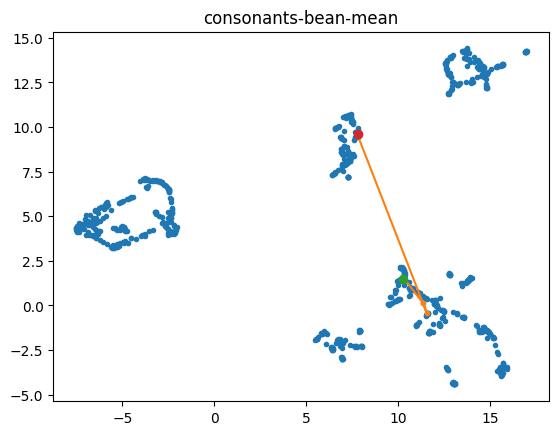

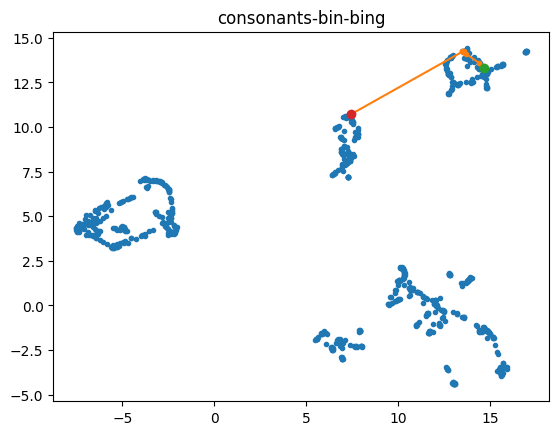

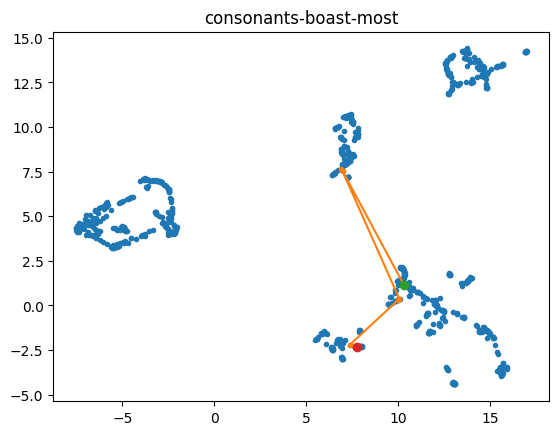

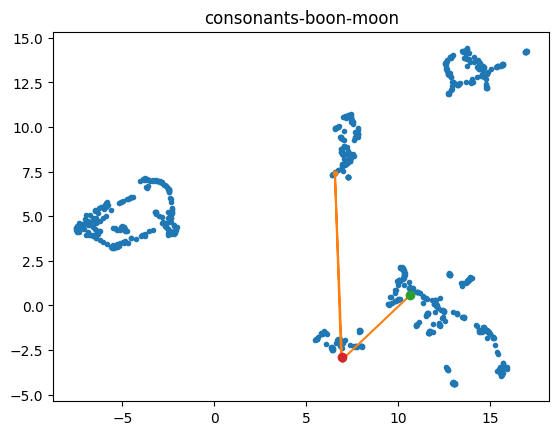

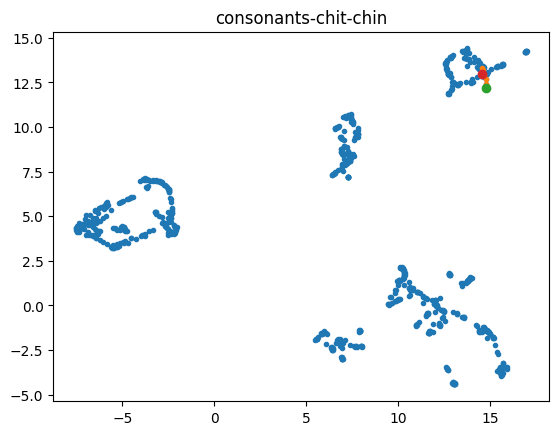

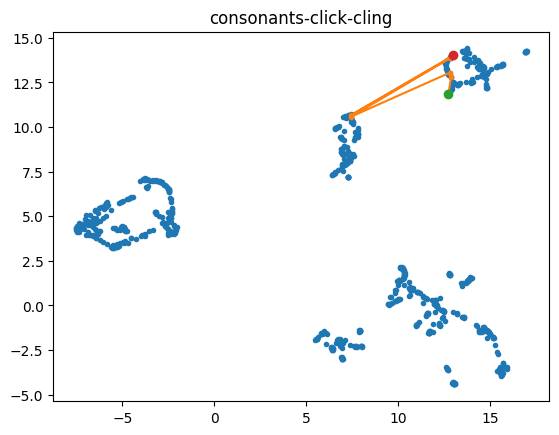

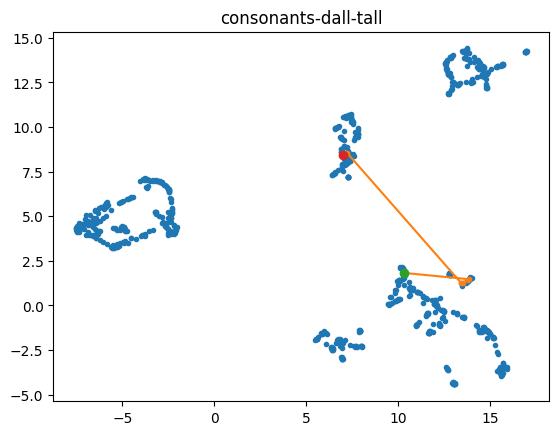

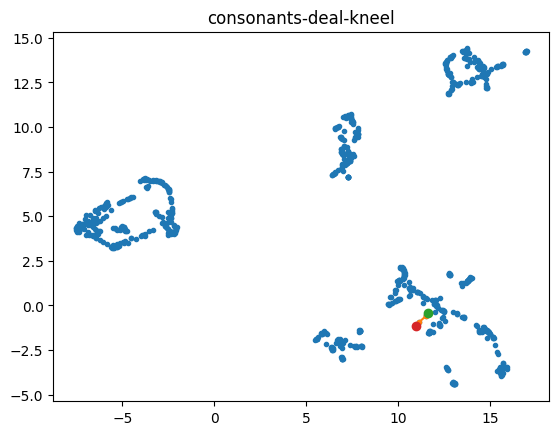

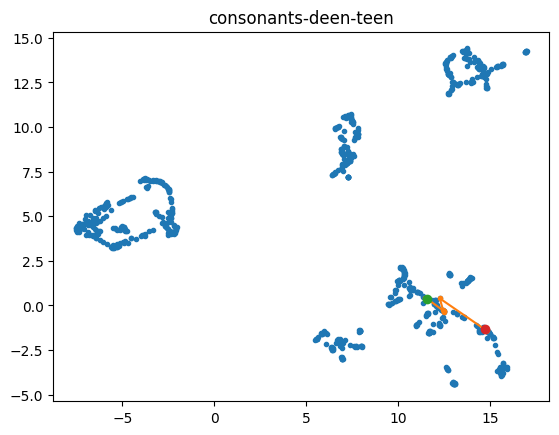

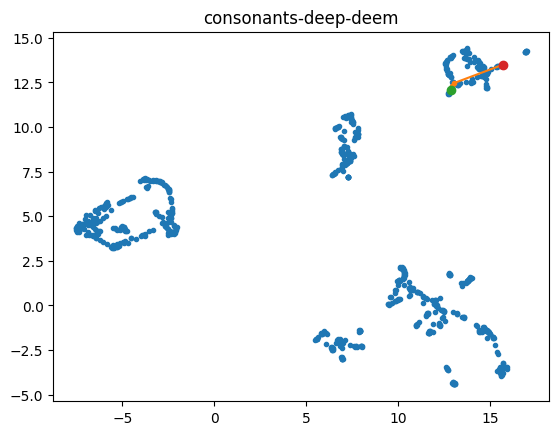

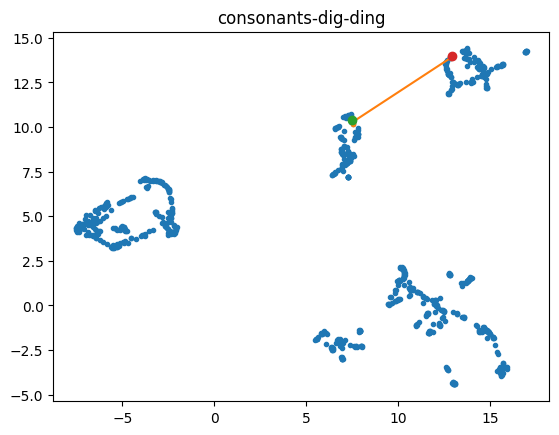

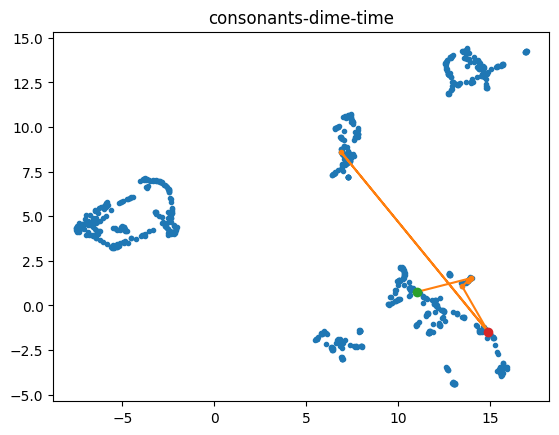

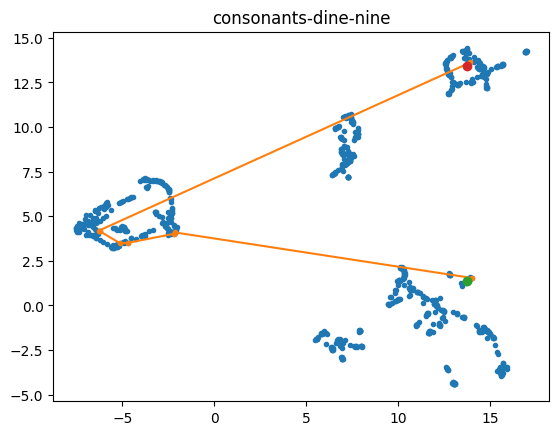

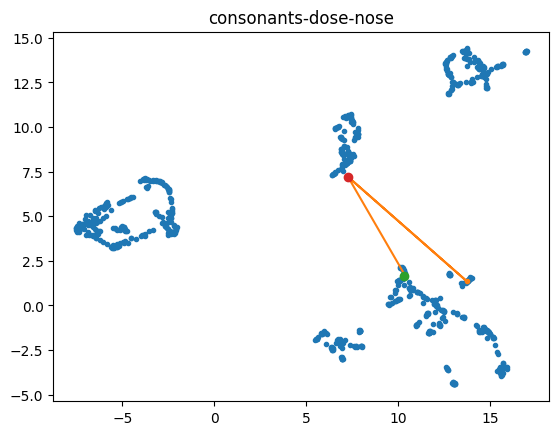

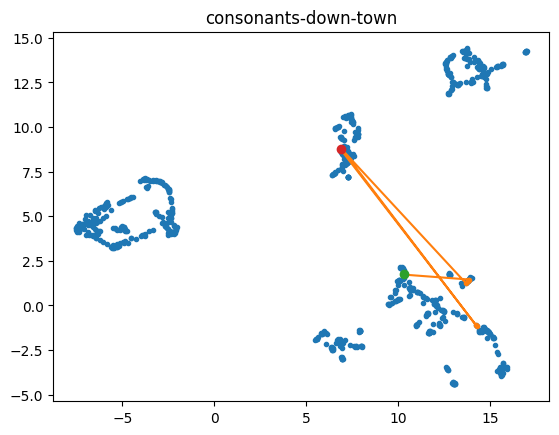

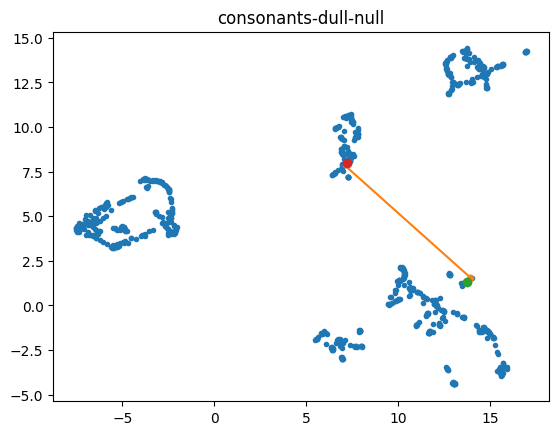

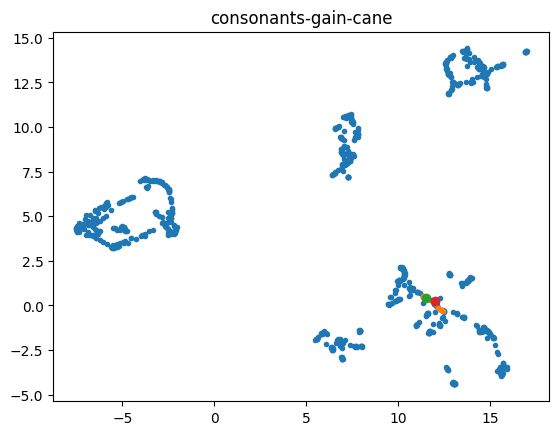

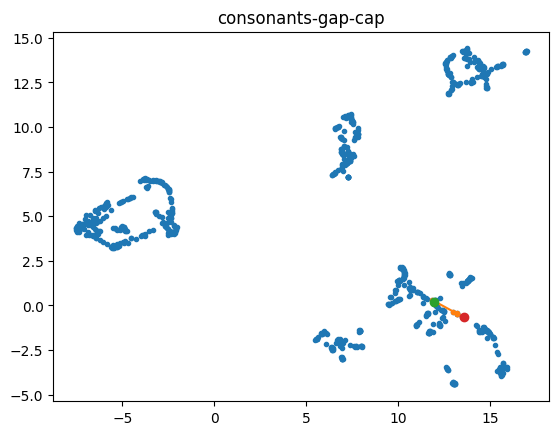

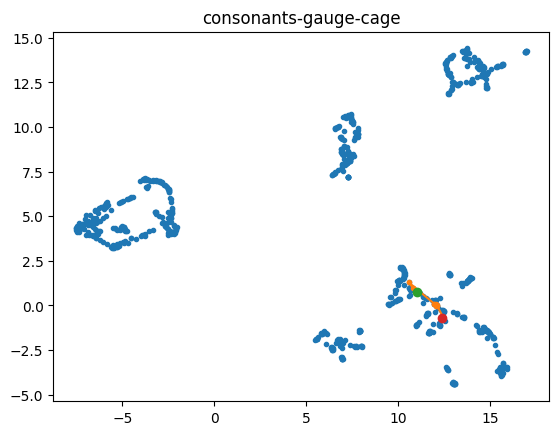

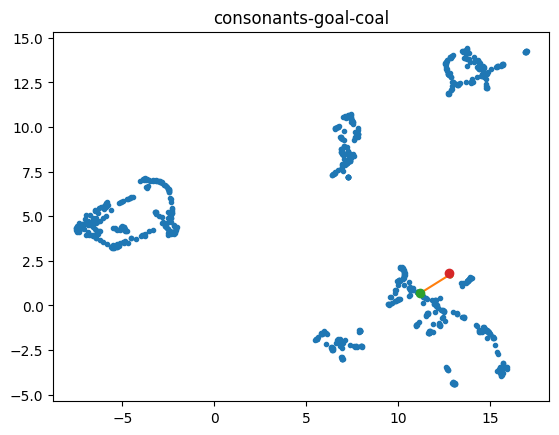

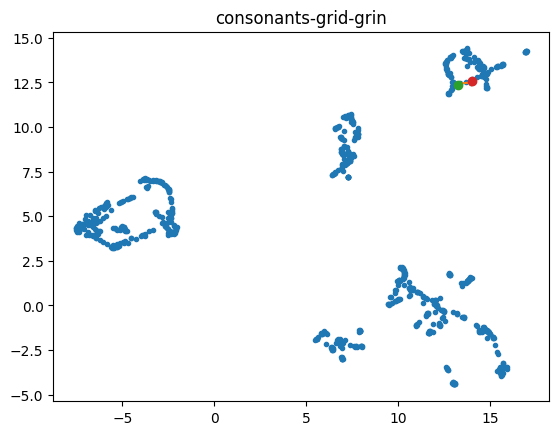

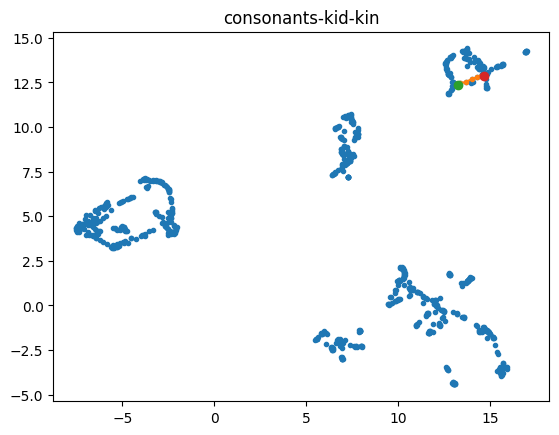

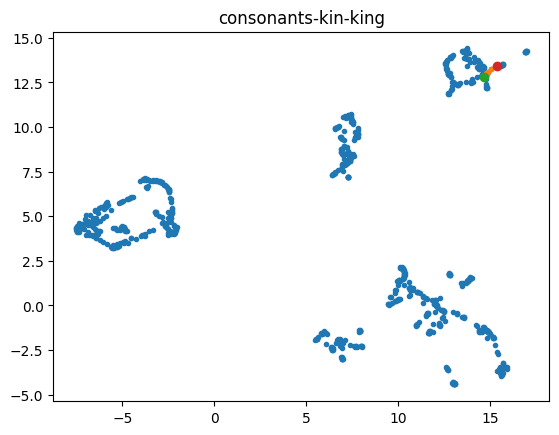

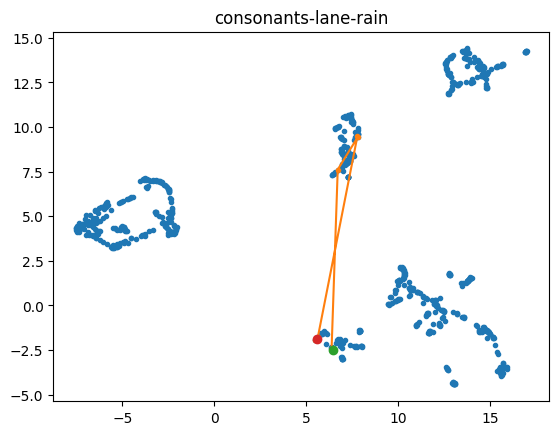

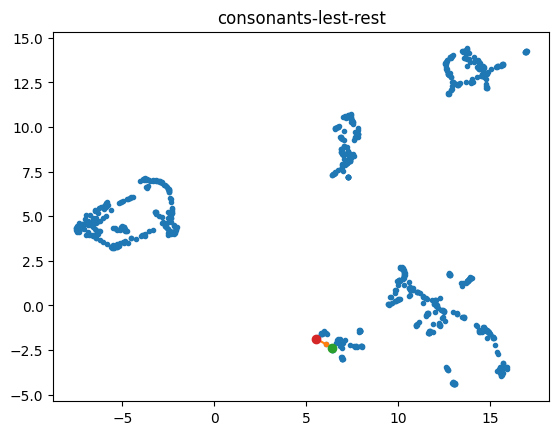

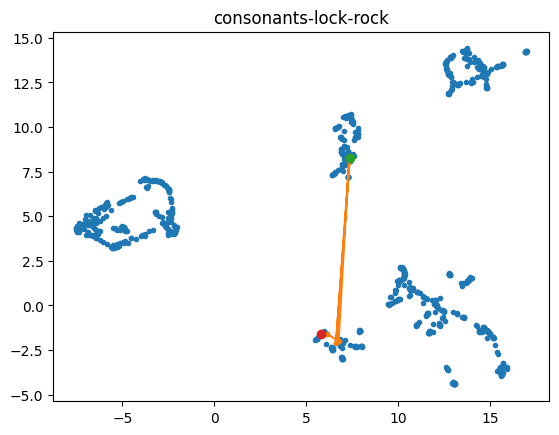

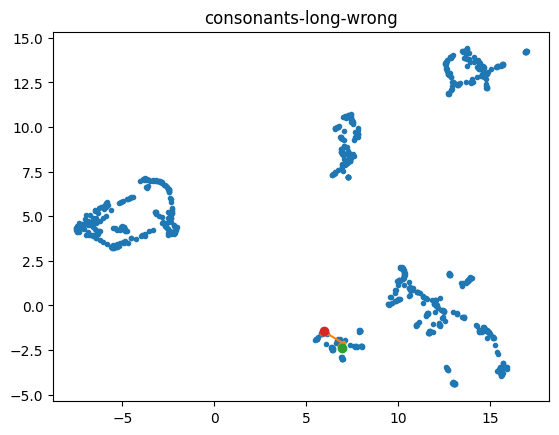

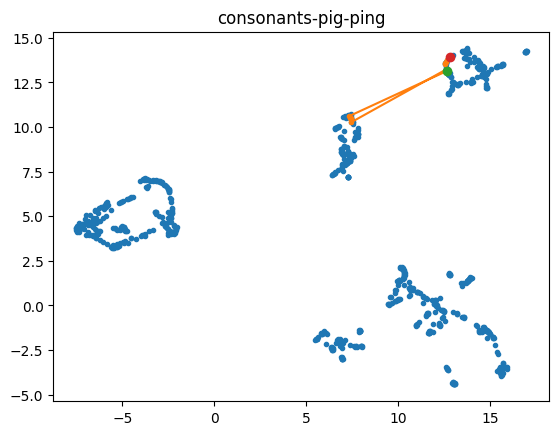

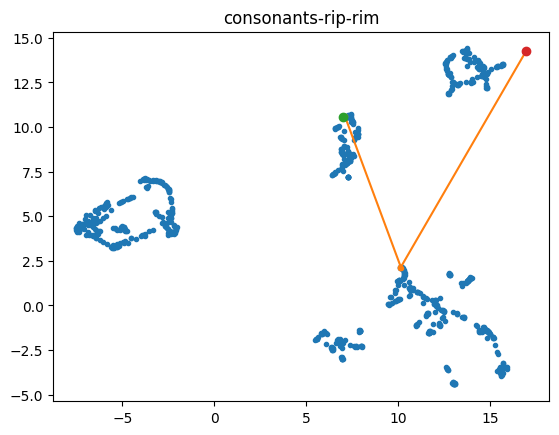

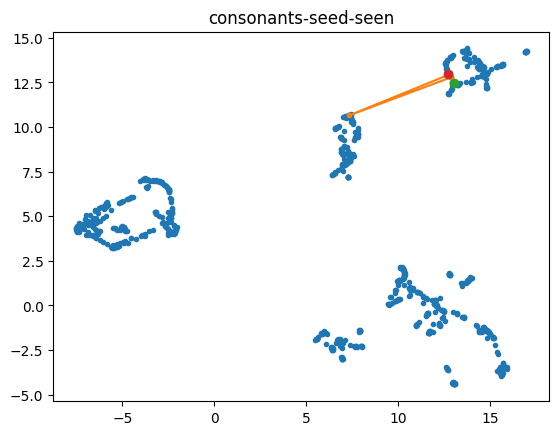

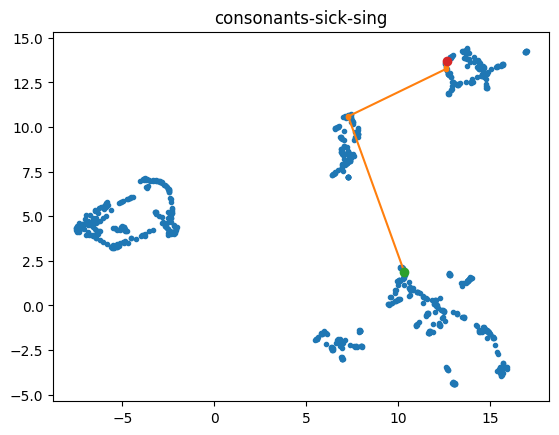

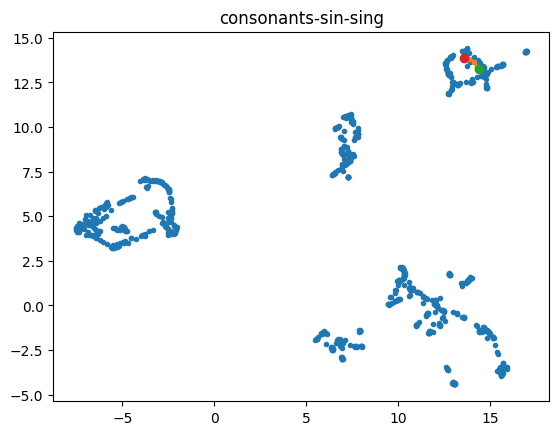

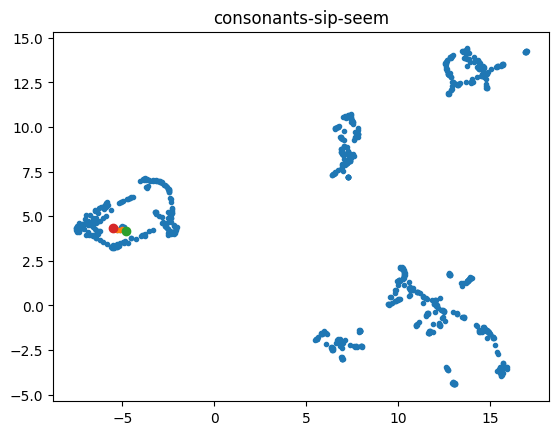

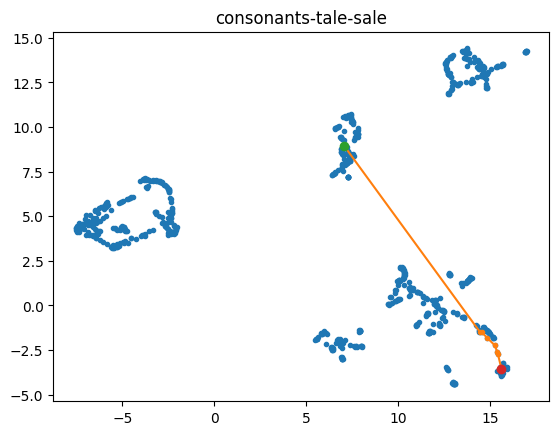

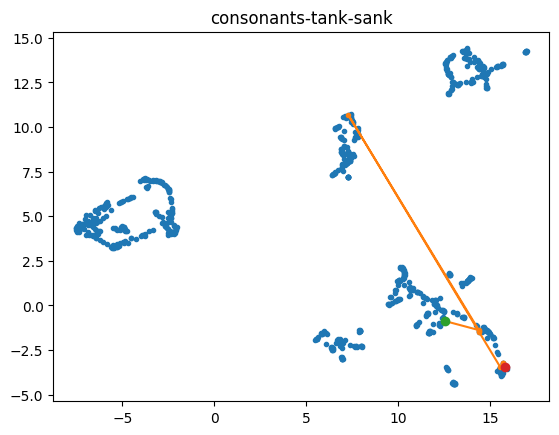

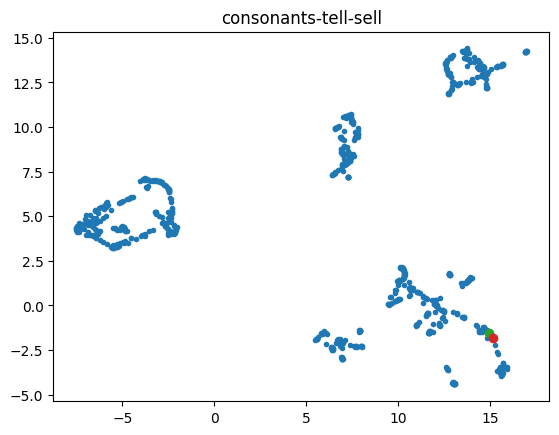

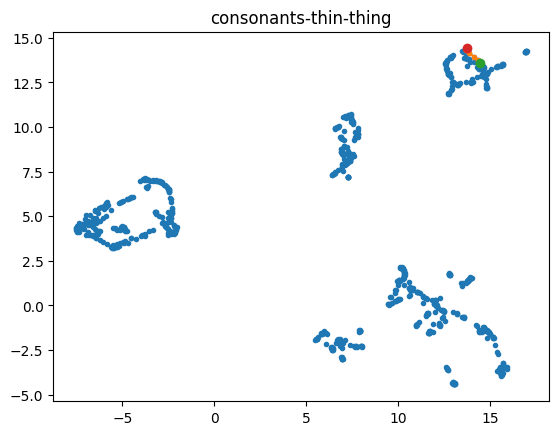

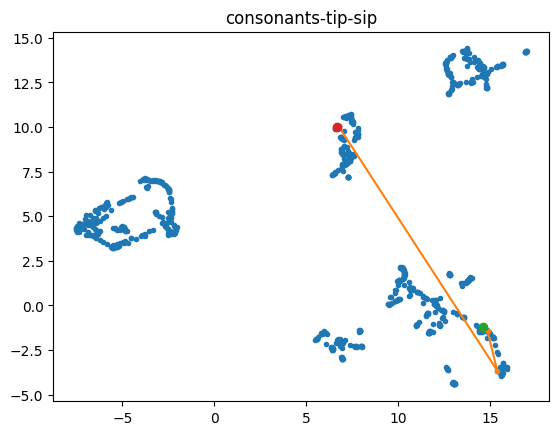

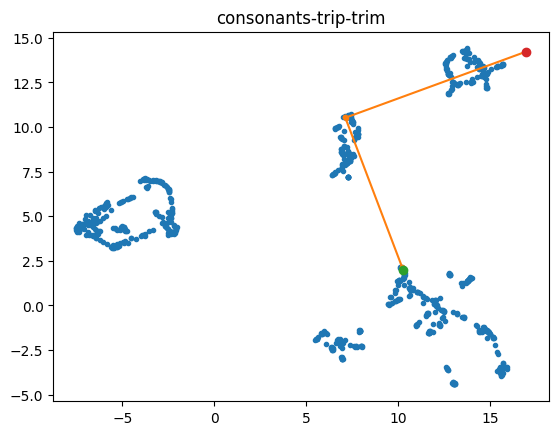

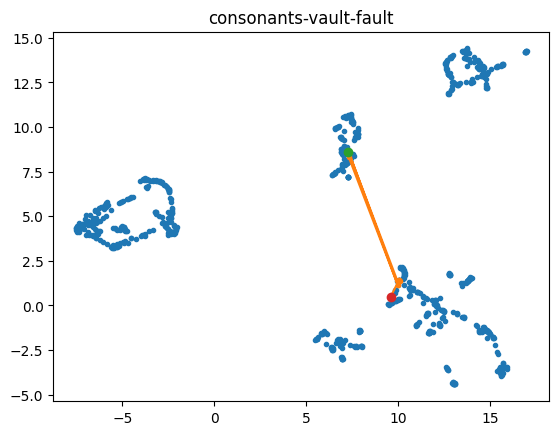

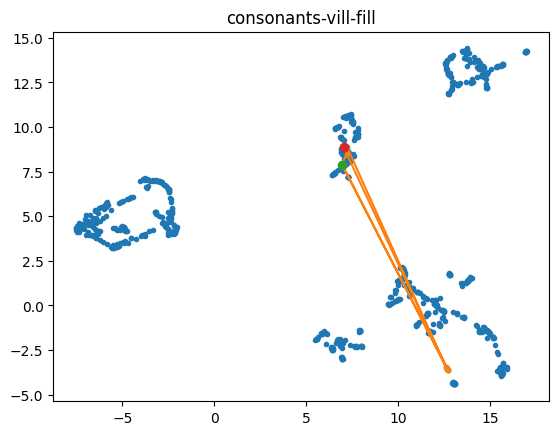

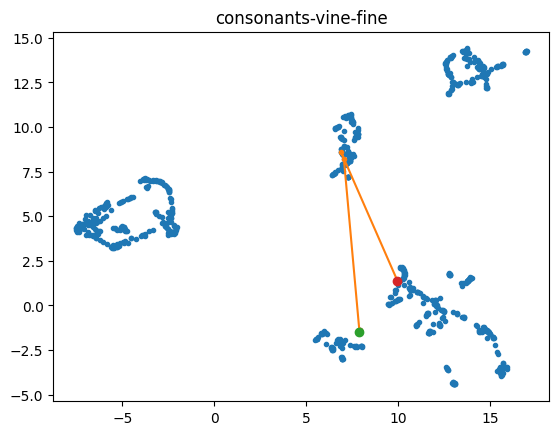

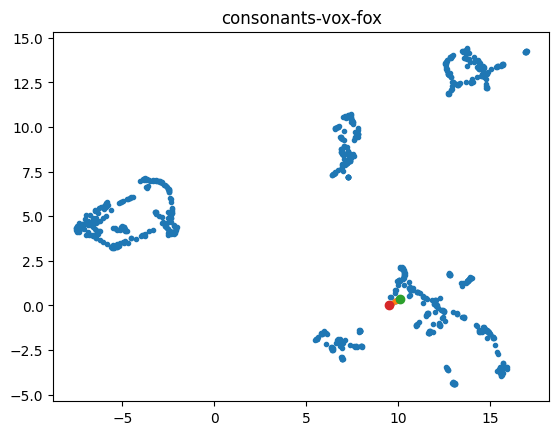

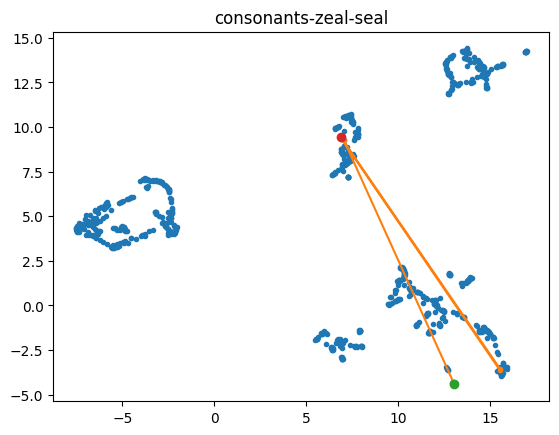

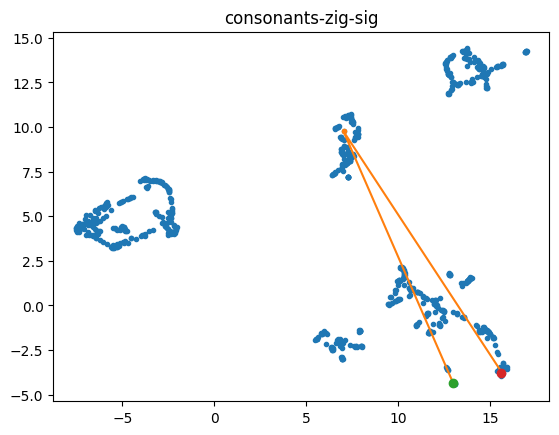

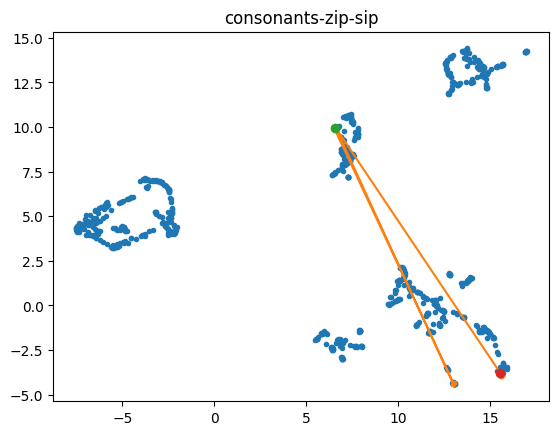

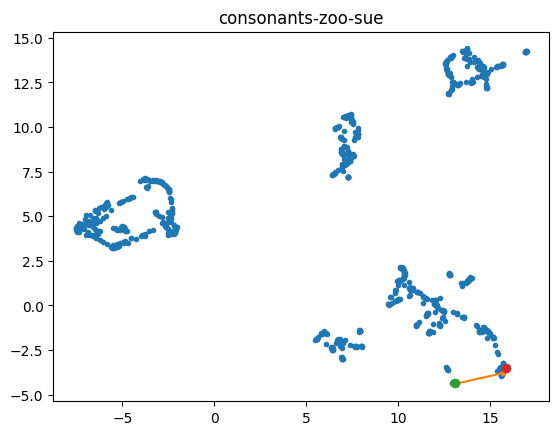

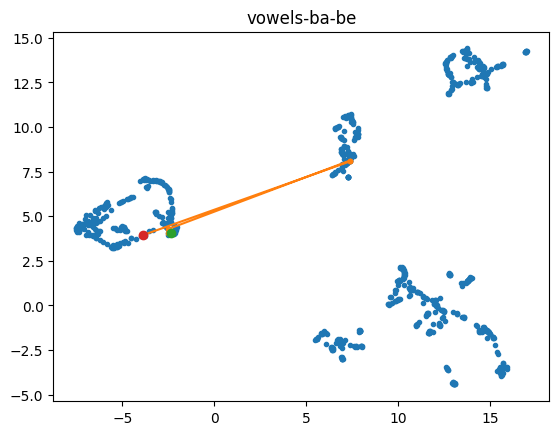

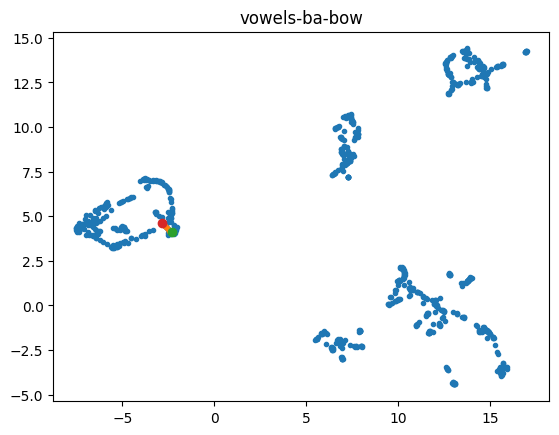

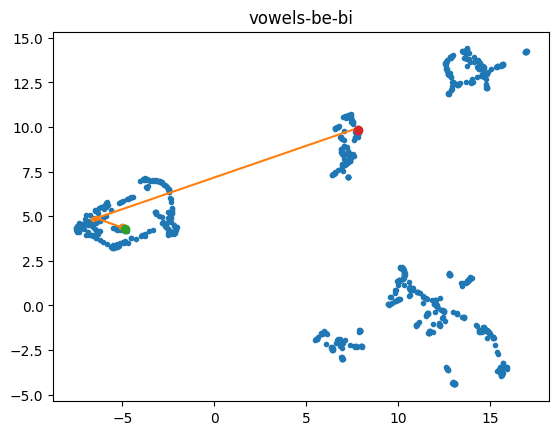

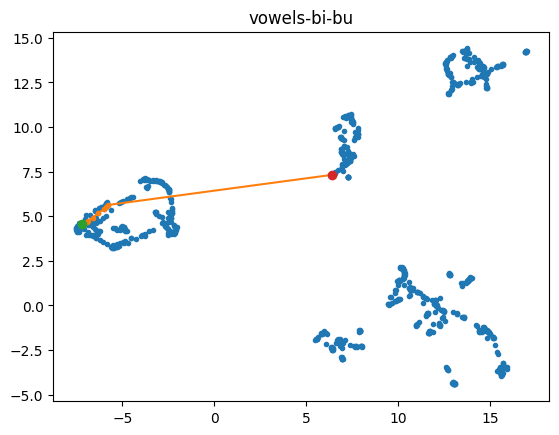

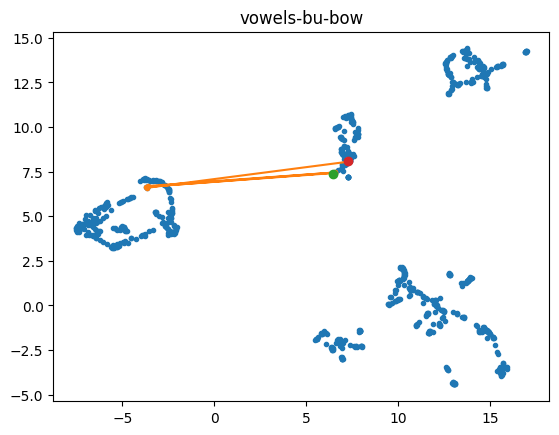

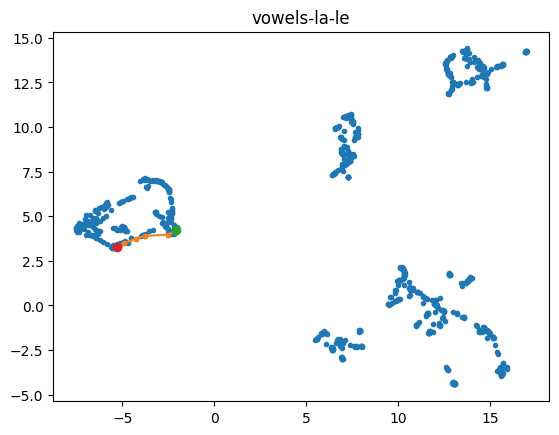

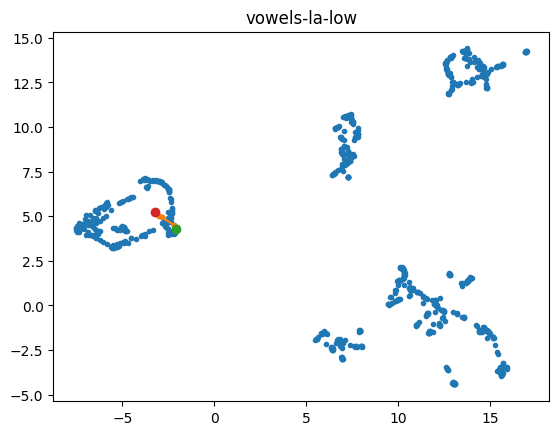

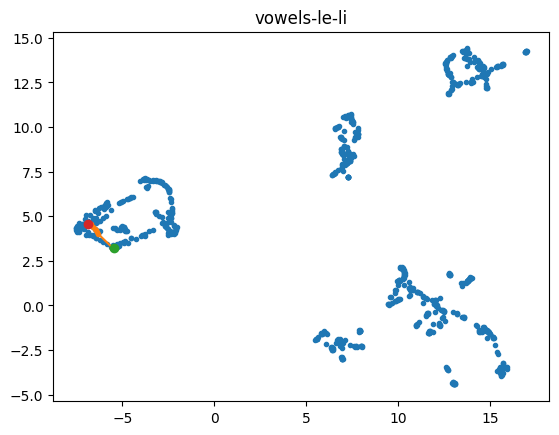

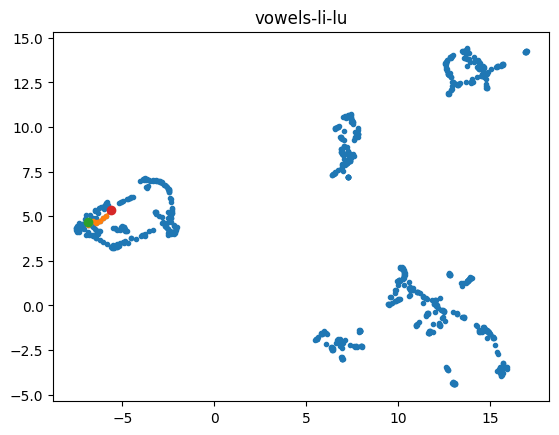

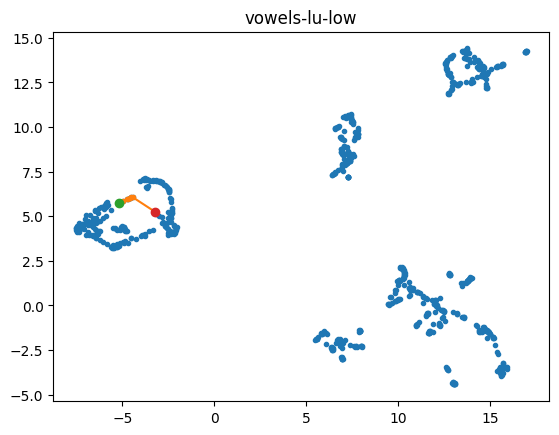

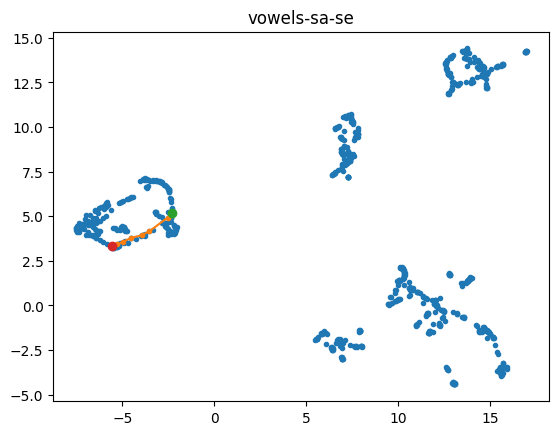

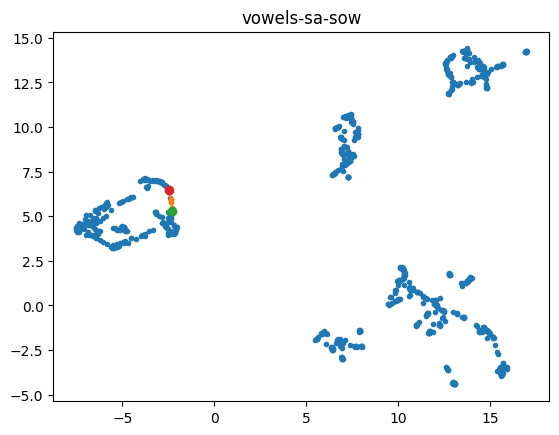

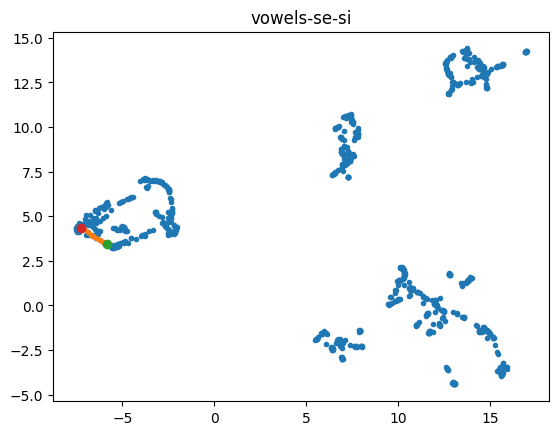

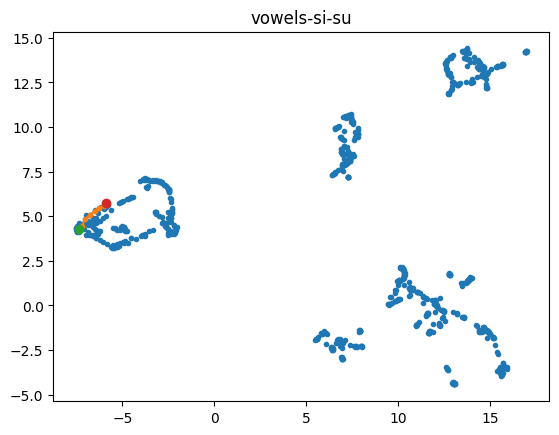

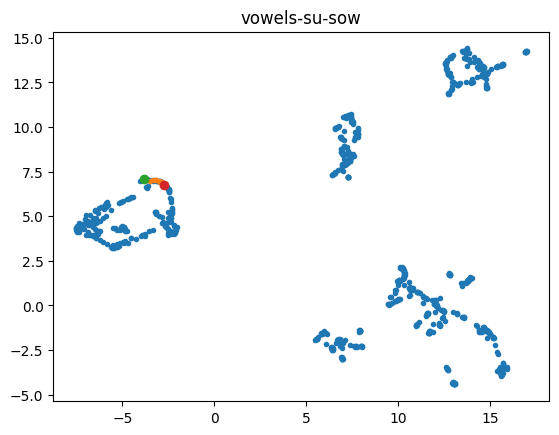

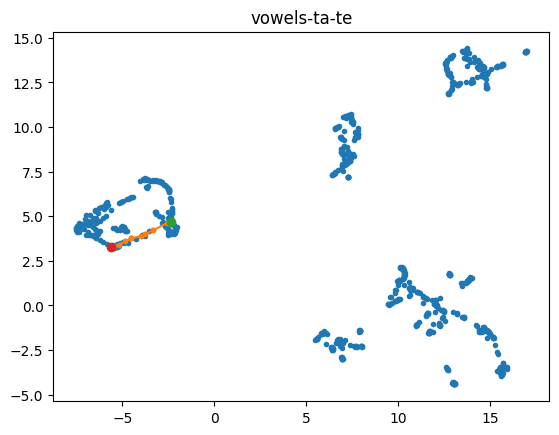

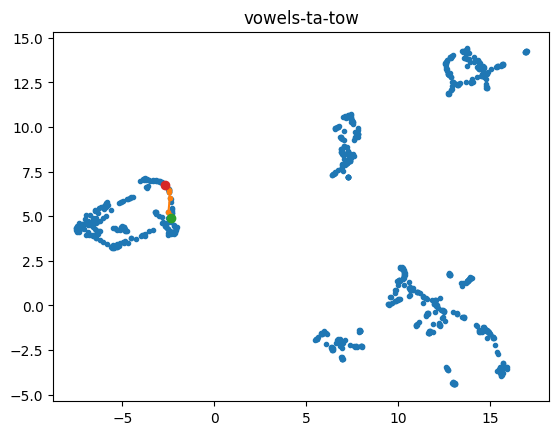

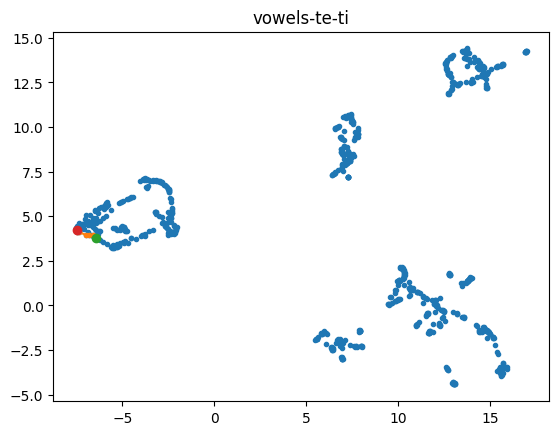

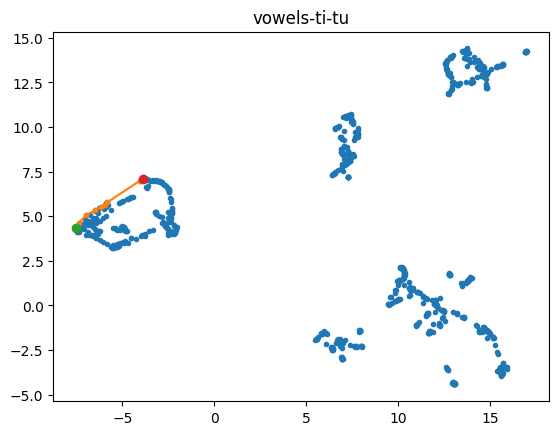

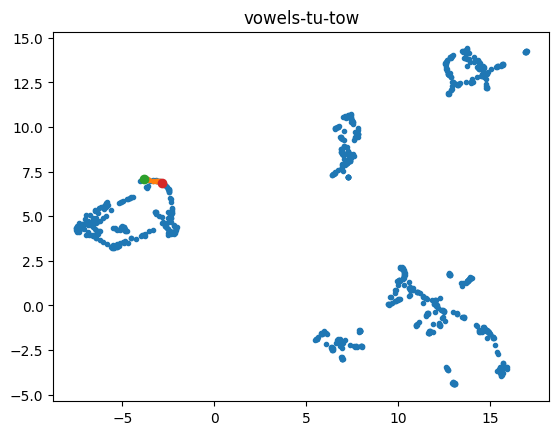

In [4]:
for i, cont in enumerate(df.continuum.unique()):
    plt.plot(embs[:,0], embs[:,1], ".")
    _embs = embs[df[df.continuum == cont].index]
    plt.plot(_embs[:, 0], _embs[:, 1], ".-")
    plt.plot(_embs[0, 0], _embs[0, 1], "o")
    plt.plot(_embs[-1, 0], _embs[-1, 1], "o")
    plt.title(cont)
    plt.show()

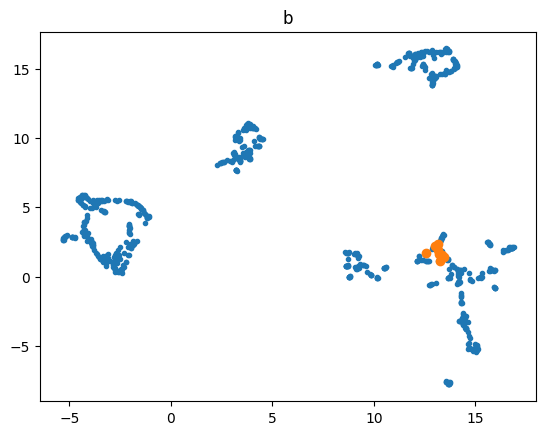

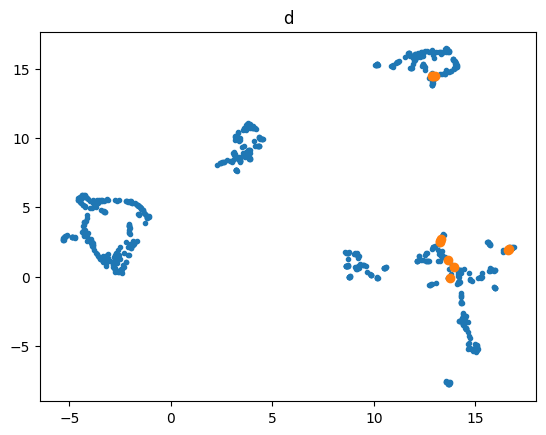

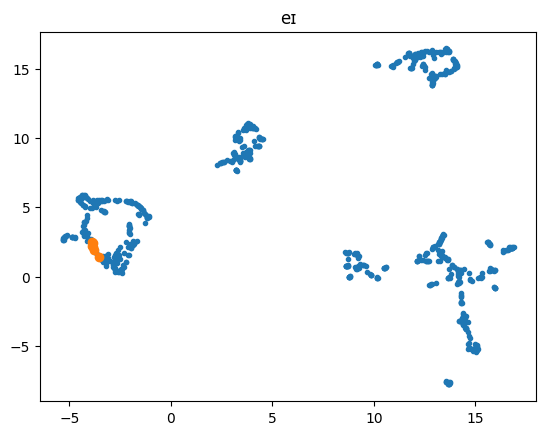

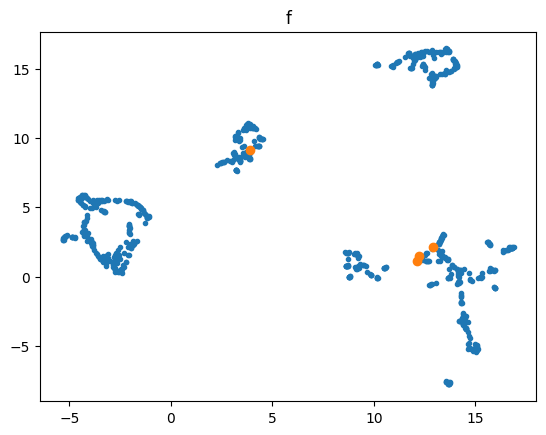

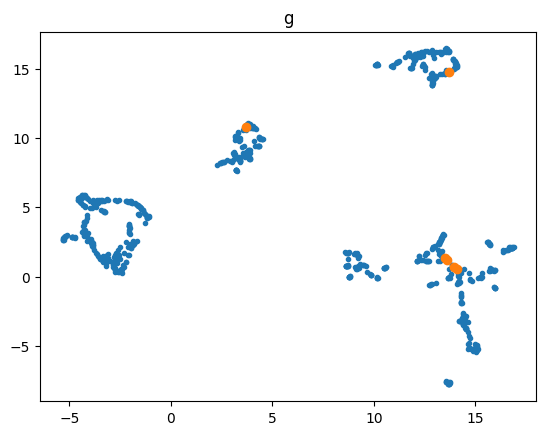

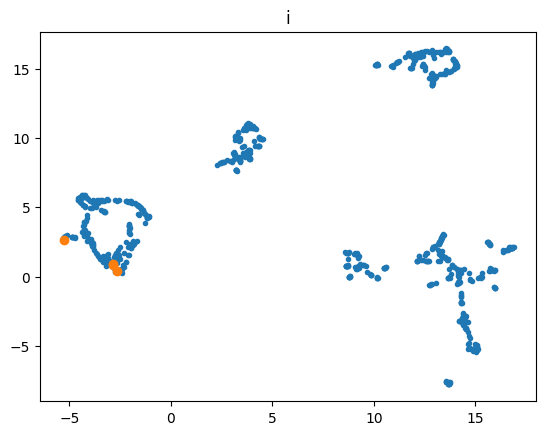

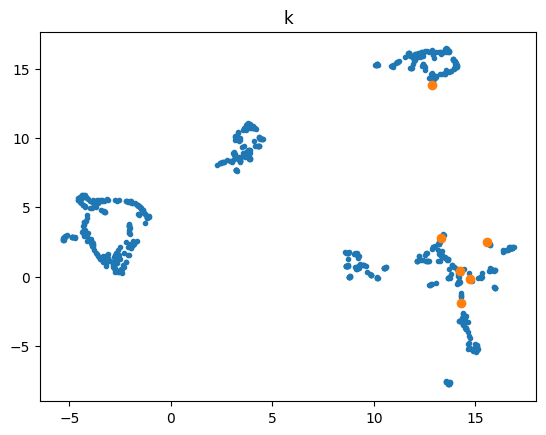

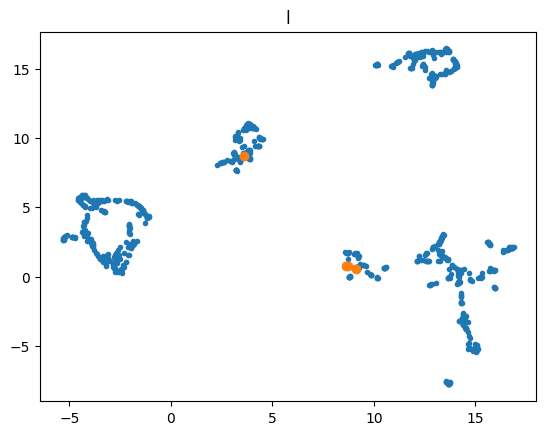

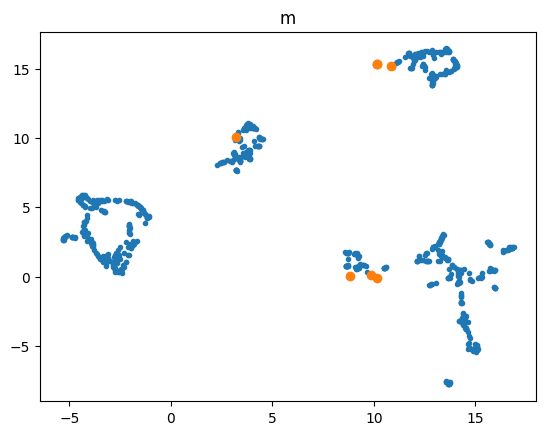

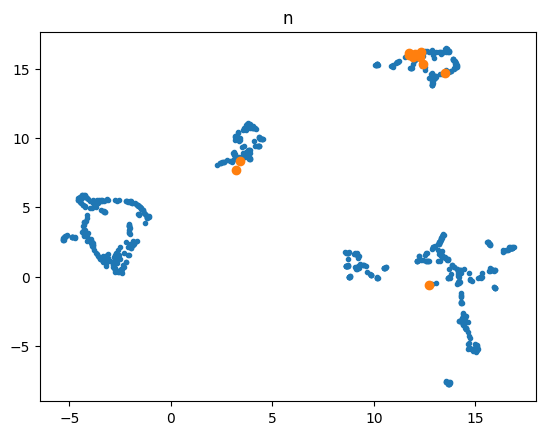

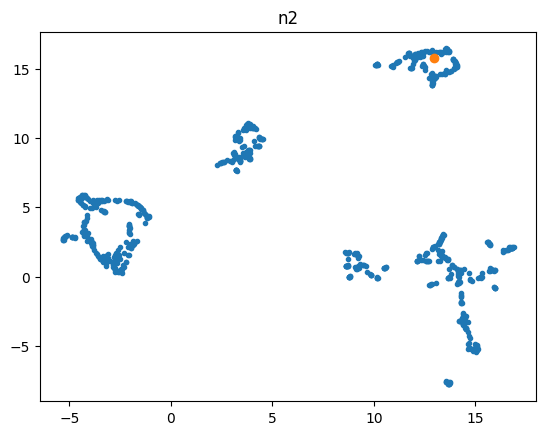

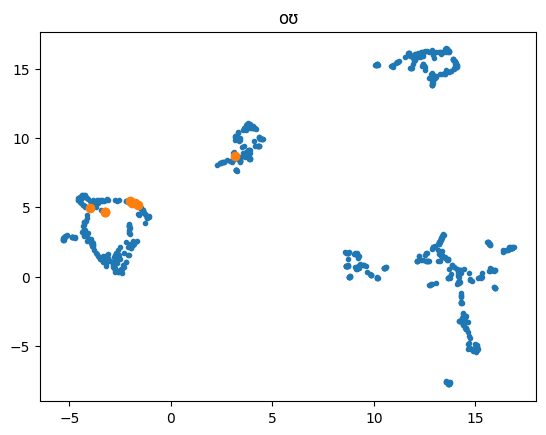

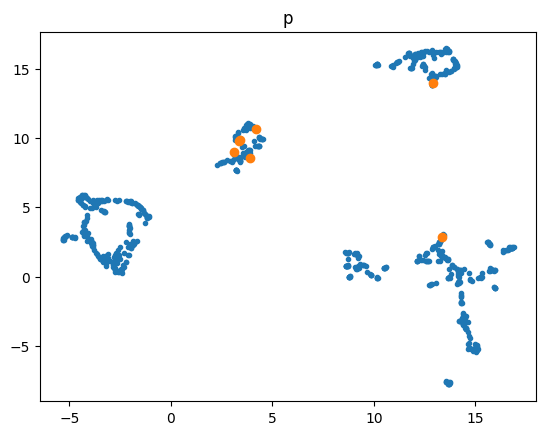

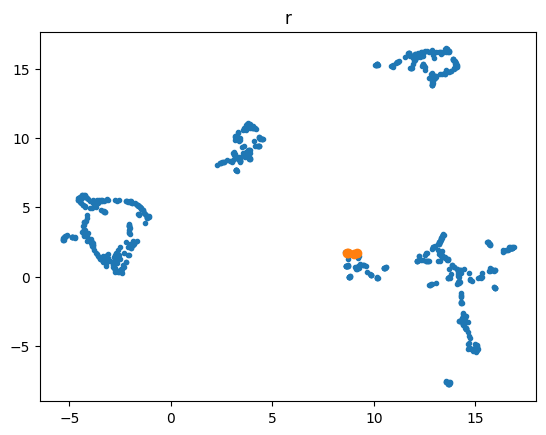

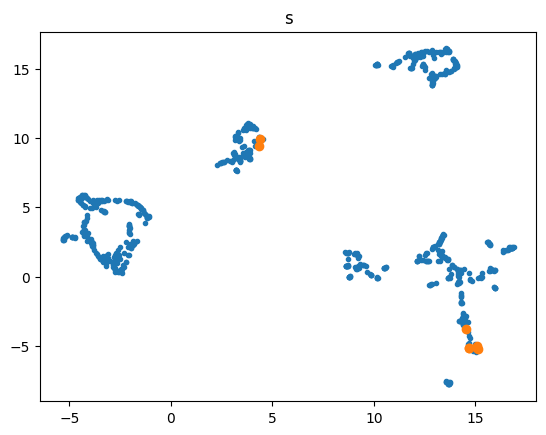

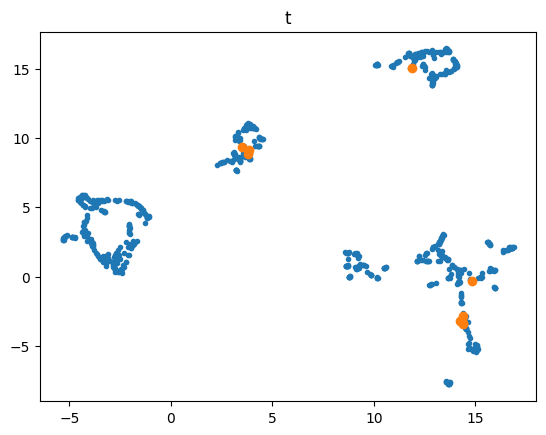

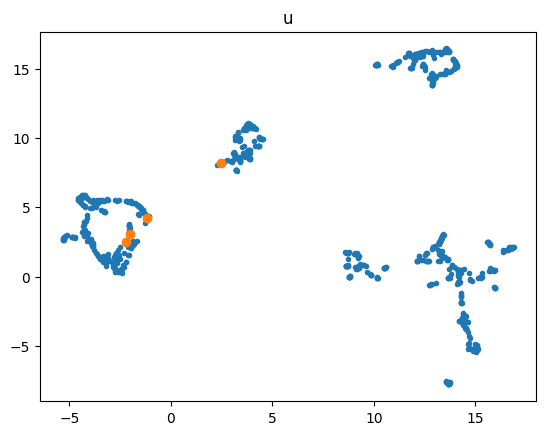

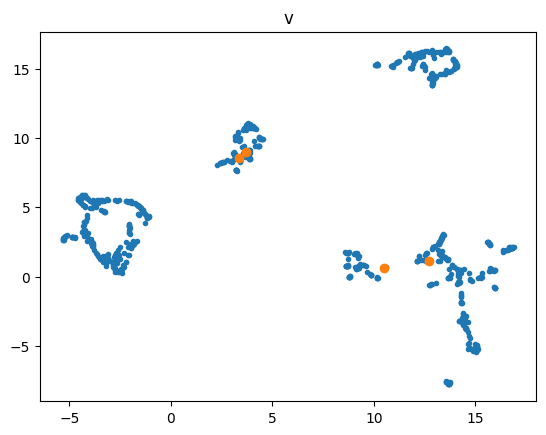

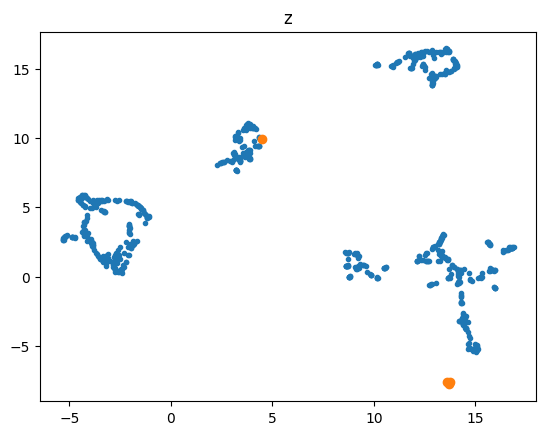

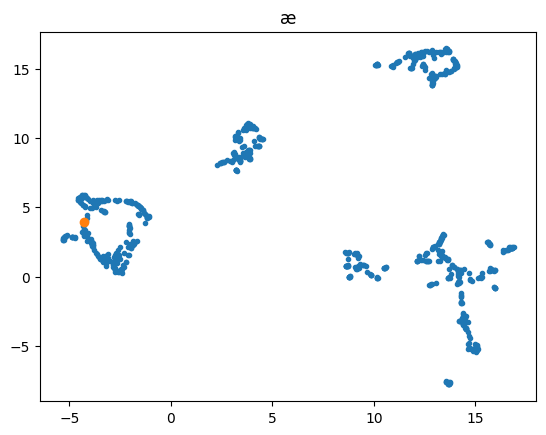

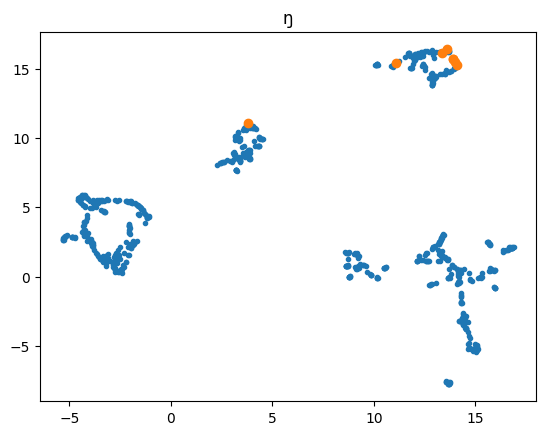

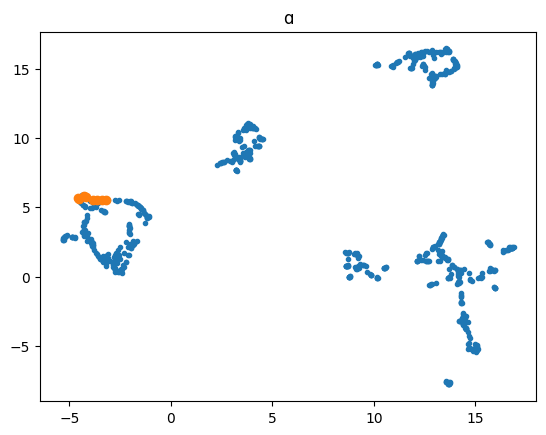

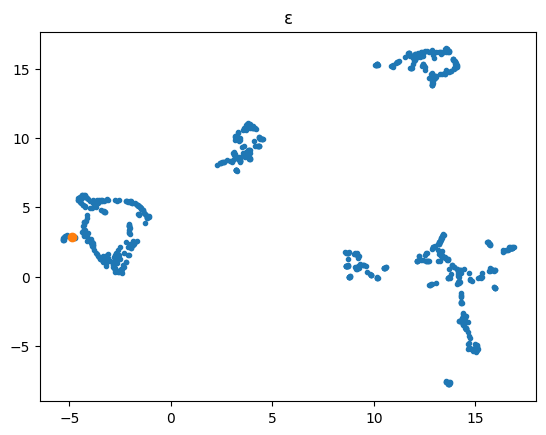

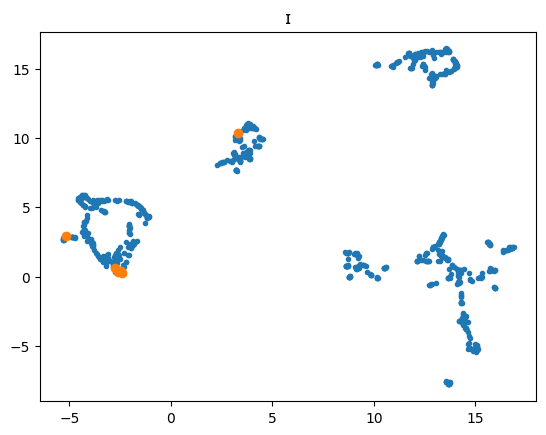

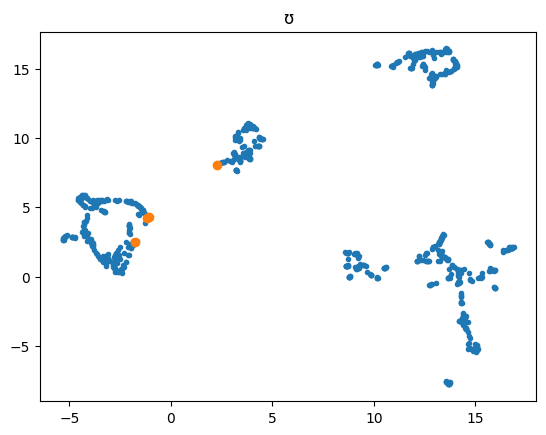

In [4]:
for i, phn in enumerate(sorted(set(df.phn_start.unique()) | set(df.phn_end.unique()))):
    plt.plot(embs[:,0], embs[:,1], ".")
    _embs = embs[df[((df.phn_start == phn) & (df.step == 0)) | ((df.phn_end == phn) & (df.step == 10))].index]
    plt.plot(_embs[:, 0], _embs[:, 1], "o")
    plt.title(phn)
    plt.show()